In [6]:
%load_ext autoreload
%autoreload 2


import glob
import os
import ozy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import pandas as pd
from collections import defaultdict
import scipy.constants as constants


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/'
ozy_files = []
for filename in glob.glob(os.path.join(directory, '*.hdf5')):
    ozy_files.append(filename)

ozy_file = ozy_files[0]

print(ozy_file)



/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/ozy_00925.hdf5


In [8]:
import os
import glob
import numpy as np
from scipy import constants
from collections import defaultdict
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, OptimizeWarning
import warnings
import pandas as pd


def run(gal_number, ozy_file, sim):

    if sim == 'NH':
    
        directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/'

        star_name = '*star*_' + str(gal_number) + '.hdf5'
        dm_name = '*dm*_' + str(gal_number) + '.hdf5'

        stars_files = []
        for filename in glob.glob(os.path.join(directory, star_name)):
            stars_files.append(filename)

        dm_files = []
        for filename in glob.glob(os.path.join(directory, dm_name)):
            dm_files.append(filename)

        directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/gas_files/'

        gas_name = '*gas*_' + str(gal_number) + '.hdf5'

        gas_files = []
        for filename in glob.glob(os.path.join(directory, gas_name)):
            gas_files.append(filename)


        from dynamics import load_all_data

        star_filename = stars_files[0]
        dm_filename = dm_files[0]
        print(star_filename)
        print(dm_filename)
        gas_filename = gas_files[0]

        star_data, dm_data, gas_data, mass_multiplier, length_multiplier, time_multiplier = load_all_data(star_filename, dm_filename, gas_filename, ozy_file)

        gas_positions = np.column_stack((gas_data['x'], gas_data['y'], gas_data['z']))
        gas_velocities = np.column_stack((gas_data['vx'], gas_data['vy'], gas_data['vz']))
        gas_masses = gas_data['mass']

        h1_positions = np.column_stack((gas_data['h1_x'], gas_data['h1_y'], gas_data['h1_z']))
        h1_velocities = np.column_stack((gas_data['h1_vx'], gas_data['h1_vy'], gas_data['h1_vz']))
        h1_masses = gas_data['h1_mass']
        h1_densities = gas_data['h1_density']

        Msun = 1.989e30
        kpc_to_m = 3.086e19
        kpc_to_km = 3.086e16


        #Variables with dm infront are from dm and any without are from the baryonic matter

        xdata = star_data['x'].value
        ydata = star_data['y'].value
        zdata = star_data['z'].value

        vxdata = star_data['vx'].value
        vydata = star_data['vy'].value
        vzdata = star_data['vz'].value

        massdata = star_data['mass'].value

        total_mass = np.sum(massdata)
        print('Total mass of the galaxy is: ', total_mass)
        #DM data

        dm_xdata = dm_data['x'].value
        dm_ydata = dm_data['y'].value
        dm_zdata = dm_data['z'].value

        dm_vxdata = dm_data['vx'].value
        dm_vydata = dm_data['vy'].value
        dm_vzdata = dm_data['vz'].value

        dm_massdata = dm_data['mass'].value


    if sim == 'TNG':

        from dynamics import load_all_data_TNG

        star_data, dm_data, gas_data  = load_all_data_TNG(int(gal_number))
        
        Msun = 1.989e30
        kpc_to_m = 3.086e19
        kpc_to_km = 3.086e16

        Msun_to_H = 1.9885e30/ 1.6726219e-27  # Convert solar mass to hydrogen atoms
        kpc_to_cm = 3.086e21  # Convert kpc to cm


        if len(star_data['positions']) == 0 or len(star_data['velocities']) == 0:
            print('No data found for galaxy number: ', gal_number)

        #Variables with dm infront are from dm and any without are from the baryonic matter

        xdata = star_data['positions'][:, 0]
        ydata = star_data['positions'][:, 1]
        zdata = star_data['positions'][:, 2]

        vxdata = star_data['velocities'][:, 0]
        vydata = star_data['velocities'][:, 1]
        vzdata = star_data['velocities'][:, 2]

        massdata = np.array(star_data['masses'])

        stellar_mass = np.sum(massdata)
        print('Stellar mass of the galaxy is: ', stellar_mass)

        if stellar_mass == 0:
            print('No stellar mass found for galaxy number: ', gal_number)

        #DM data

        dm_xdata = dm_data['positions'][:, 0]
        dm_ydata = dm_data['positions'][:, 1]
        dm_zdata = dm_data['positions'][:, 2]

        dm_vxdata = dm_data['velocities'][:, 0]
        dm_vydata = dm_data['velocities'][:, 1]
        dm_vzdata = dm_data['velocities'][:, 2]

        dm_massdata = np.array(dm_data['masses'])

        dm_mass = np.sum(dm_massdata)
        print('Dark matter mass of the galaxy is: ', dm_mass)

        #Gas data

        gas_xdata = gas_data['positions'][:, 0]
        gas_ydata = gas_data['positions'][:, 1]
        gas_zdata = gas_data['positions'][:, 2]

        gas_vxdata = gas_data['velocities'][:, 0]
        gas_vydata = gas_data['velocities'][:, 1]
        gas_vzdata = gas_data['velocities'][:, 2]

        gas_velocities = np.column_stack((gas_vxdata, gas_vydata, gas_vzdata))
        gas_positions = np.column_stack((gas_xdata, gas_ydata, gas_zdata))

        gas_masses = np.array(gas_data['masses'])

        gas_densities = np.array(gas_data['densities'])

        H1_frac = np.array(gas_data['H1_frac'])

        H1_masses = gas_masses * H1_frac

        H1_densities = gas_densities * H1_frac

        h1_positions = gas_positions
        h1_velocities = gas_velocities
        h1_masses = H1_masses
        h1_densities = H1_densities

        
    Msun = 1.989e30
    kpc_to_m = 3.086e19
    kpc_to_km = 3.086e16

    #Calculate the distance from the centre of the galaxy

    rdata = np.sqrt(xdata**2 + ydata**2 + zdata**2)
    dm_rdata = np.sqrt(dm_xdata**2 + dm_ydata**2 + dm_zdata**2)

    points = np.column_stack((xdata, ydata, zdata))
    dm_points = np.column_stack((dm_xdata, dm_ydata, dm_zdata))

    #Need to move into center of mass frame of the galaxy

    velocities = np.column_stack((vxdata, vydata, vzdata))
    dm_velocities = np.column_stack((dm_vxdata, dm_vydata, dm_vzdata))


    #Sort the data by distance from the centre of the galaxy
    #Create an array called mapping which has the final after its sorted in terms of distance, therefore any other data can be sorted in the same way

    from dynamics import create_rotation_matrix

    rotation_matrix = create_rotation_matrix(h1_velocities, h1_positions, h1_masses, False)

    if np.isnan(rotation_matrix).any():
        print('Rotation matrix contains NaN values for galaxy number: ', gal_number)
        return None

    #Now apply the rotation matrix to the velocity vectors

    velocities_rotated = np.dot(rotation_matrix, velocities[:][:].T).T
    rotated_points = np.dot(rotation_matrix, points[:][:].T).T

    gas_velocities_rotated = np.dot(rotation_matrix, gas_velocities.T).T
    gas_positions_rotated = np.dot(rotation_matrix, gas_positions.T).T

    h1_velocities_rotated = np.dot(rotation_matrix, h1_velocities.T).T
    h1_positions_rotated = np.dot(rotation_matrix, h1_positions.T).T

    #MAYBE DELETE

    # if sim == 'TNG':
    #     galaxies_dataframe = pd.read_csv('/mnt/users/darnej/MPhys/TNG-50/Galaxy_dataframe_TNG.csv')
    #     zgas_1_2 = galaxies_dataframe['gas_z_half'][galaxies_dataframe['gal_number'] == gal_number].values[0]
    #     mask = abs(h1_positions_rotated[:,2]) <= 3*zgas_1_2

    #     h1_velocities_rotated = h1_velocities_rotated[mask]
    #     h1_positions_rotated = h1_positions_rotated[mask]
    #     h1_masses = h1_masses[mask]
    #     h1_densities = h1_densities[mask]

    if sim == 'TNG':

        x = np.log10(h1_densities) + np.log10(Msun_to_H / (kpc_to_cm**3))  # Convert densities to log scale
        h1_densities = 10**x  # Convert back to linear scale


        mask = h1_densities > 0.01
        h1_velocities_rotated = h1_velocities_rotated[mask]
        h1_positions_rotated = h1_positions_rotated[mask]
        h1_masses = h1_masses[mask]
        h1_densities = h1_densities[mask]

    if sim == 'NH':

        velocities_rotated = np.append(velocities_rotated, gas_velocities_rotated.value, axis=0)
        rotated_points = np.append(rotated_points, gas_positions_rotated, axis=0)
        massdata = np.append(massdata, gas_masses.value)
    
    if sim == 'TNG':
        velocities_rotated = np.append(velocities_rotated, gas_velocities_rotated, axis=0)
        rotated_points = np.append(rotated_points, gas_positions_rotated, axis=0)
        massdata = np.append(massdata, gas_masses)

    rdata = np.append(rdata, np.sqrt(gas_positions[:,0]**2 + gas_positions[:,1]**2 + gas_positions[:,2]**2))


    #Now we want to change the velocities from cartesian to cylindrical coordinates
    #If r = sqrt(x^2 + y^2) then vr = (x(xdot) + y(ydot))/r
    #If tan(theta) = y/x then vtheta = ((ydot)x - y(xdot))/r^2

    def cartesian_to_cylindrical_velocity(vx, vy, vz, x, y):
        vr = (x*vx + y*vy)/(x**2 + y**2)**0.5
        vtheta = (x*vy - y*vx)/(x**2 + y**2)**0.5
        vz = vz
        return np.array([vr, vtheta, vz]).T


    h1_cylindrical_velocities = cartesian_to_cylindrical_velocity(h1_velocities_rotated[:,0],h1_velocities_rotated[:,1], h1_velocities_rotated[:,2], h1_positions_rotated[:,0], h1_positions_rotated[:,1])

    v_theta_h1 = h1_cylindrical_velocities[:,1]


    #Now need to convert the points from cartesian to cylindrical coordinates

    def cartesian_to_cylindrical_points(x, y, z):
        r = (x**2 + y**2)**0.5
        theta = np.arctan2(y, x)
        z = z
        return np.array([r, theta, z]).T

    gas_cylindrical_points = cartesian_to_cylindrical_points(gas_positions_rotated[:,0], gas_positions_rotated[:,1], gas_positions_rotated[:,2])

    gas_cylindrical_shells = gas_cylindrical_points[:,0] #r points

    h1_cylindrical_points = cartesian_to_cylindrical_points(h1_positions_rotated[:,0], h1_positions_rotated[:,1], h1_positions_rotated[:,2])

    h1_cylindrical_shells = h1_cylindrical_points[:,0] #r points
    

    #FINDING ALL ACCELERATIONS AND VELOCITIES

    #Want 30 bins between r = 0 and r = 5*Rgas_1/2

    if sim == 'NH':

        dataframe = pd.read_csv('/mnt/users/darnej/MPhys/galaxies_dataframe.csv')

        R_1_2 = dataframe['gas_r_half'][int(gal_number)-1]

        gas_z_half = dataframe['gas_z_half'][int(gal_number)-1]
    
    if sim == 'TNG':

        dataframe = pd.read_csv('/mnt/users/darnej/MPhys/TNG-50/Galaxy_dataframe_TNG.csv')

        gal_numbers = np.array(dataframe['gal_number'])

        R_1_2 = dataframe['gas_r_half'][gal_numbers == gal_number].values[0]

        gas_z_half = dataframe['gas_z_half'][gal_numbers == gal_number].values[0]
    

    number_of_bins = 30
  
    bins = np.linspace(0, 5*R_1_2, number_of_bins+1)
    bincenters = (bins[1:] + bins[:-1])/2


    mean_acc_obs = []
    mean_acc_bar = []
    total_mean_acc_bar = []
    v_obs = []


    sigma = []
    mean_r = []
    surface_density = []


    ## V_A2 = R * Sigma_p^2 * e^(R/R_d) / R_d * (R_c/arcsec + e^(R/R_d))^-1

    #For each bin we have R, need to get a value for sigma_p, R_d and R_c

    #Sigma_p is the velocity dispersion for that bin. It is calculated by sigma_p^2 = np.sum(v[i] - mean_v_theta_in_bin)**2 / (len(v_theta_in_bin) - 1)
    def get_sigma_p(v):
        mean_v = np.mean(v, axis=0)
        sigma_p_squared = np.sum(((v - mean_v) ** 2) / len(v), axis = 0)
        return np.sqrt(sigma_p_squared)

    def surface_density_model(R, f0, Rc, Rd):
        x = R / Rd
        # Use stable form when exp(x) is huge
        exp_term = np.exp(np.minimum(x, 700))
        return f0 * (Rc + 1) * (Rc + exp_term)**(-1) # Example for illustration
    


    for i in range(number_of_bins):


        max_r_for_bin = bins[i+1]
        min_r_for_bin = bins[i]

        mask = (h1_cylindrical_shells > min_r_for_bin) & (h1_cylindrical_shells < max_r_for_bin)

        v_in_bin = h1_cylindrical_velocities[mask]

        vtheta_in_bin = v_theta_h1[mask]

        mass_in_bin = h1_masses[mask]

        if len(vtheta_in_bin) != 0:

            #FINDING V_OBS AND G_OBS

            mean_v_theta_in_bin = np.average(vtheta_in_bin, weights=mass_in_bin)

            v_obs.append(mean_v_theta_in_bin)

            mean_a_in_bin = np.average(vtheta_in_bin**2 / h1_cylindrical_shells[mask], weights=mass_in_bin)

            mean_acc_obs.append(mean_a_in_bin)

            #CALCULATE ASYMMETRIC VELOCITY DRIFT


            sigma_in_bin = get_sigma_p(v_in_bin)

            sigma.append(sigma_in_bin)

            surface_dens = np.sum(mass_in_bin) / (np.pi * (max_r_for_bin**2 - min_r_for_bin**2))

            surface_density.append(surface_dens)

            mean_r.append(bincenters[i])


            #FINDING G_BAR AND V_BAR

            r_in_m = bincenters[i]*kpc_to_m
            mask = (rdata < bincenters[i])
            x = Msun / r_in_m**2
            x = x * constants.G * np.sum(massdata[mask])
            mean_acc_bar.append(x)


            #FINDING G_TOTAL AND V_TOTAL


            dm_mask = (dm_rdata < bincenters[i])
            mask = (rdata < bincenters[i])
            x = Msun / r_in_m**2
            x = x * constants.G * (np.sum(massdata[mask]) + np.sum(dm_massdata[dm_mask]))
            total_mean_acc_bar.append(x)

    

        else:
            continue

            


    mean_acc_obs = np.array(mean_acc_obs)*kpc_to_m

    mean_acc_bar = np.array(mean_acc_bar)

    v_obs = np.array(v_obs)*kpc_to_m

    total_mean_acc_bar = np.array(total_mean_acc_bar)

    sigma = np.array(sigma)

    surface_density = np.array(surface_density)

    mean_r = np.array(mean_r)


    sigma_v = np.sqrt((sigma[:,0]**2 + sigma[:,1]**2 + sigma[:,2]**2)/3)

    sigma2_SD = sigma_v**2 * surface_density #Units: Msun/s^2


    #FIND V_A USING F FITTING FUNCTION

    # Initial guess for the parameters (f_0, Rc, Rd)

    p0 = [sigma2_SD[0], 5, 5] 

    print(sigma2_SD)

    print(p0)

    if len(mean_r) < 3:
        print("Not enough data points for curve fitting. Ensure you have sufficient data in your bins.")
        return None
    
    
    try:

        with warnings.catch_warnings():
            warnings.simplefilter("error", category=RuntimeWarning)  # Turn RuntimeWarnings into errors
            warnings.simplefilter("error", category=OptimizeWarning) # Turn OptimizeWarning into errors

            # popt contains the optimal values for the parameters
            # pcov is the covariance matrix
            popt, pcov = curve_fit(surface_density_model, mean_r, sigma2_SD, p0=p0, bounds=([0, 0, 1e-3], [np.inf, np.inf, np.inf]))

            # Extract the fitted parameters
            fitted_f0, fitted_Rc, fitted_Rd = popt
            print(f"Fitted Rc: " + str(fitted_Rc))
            print(f"Fitted Rd: " + str(fitted_Rd))
            print(f"Fitted f0: " + str(fitted_f0))

    # You can then use these fitted_Rc and fitted_Rd values in your V_A calculation.
    except RuntimeError as e:
        print(f"Error during curve fitting: {e}")
        print("Try adjusting initial guesses (p0) or checking your data.")

        results = defaultdict(list)

        results['mean_acc_obs'] = mean_acc_obs
        results['mean_acc_bar'] = mean_acc_bar
        results['mean_vtheta'] = v_obs
        results['mean_r'] = bincenters
        results['total_mean_acc_bar'] = total_mean_acc_bar

        df = pd.DataFrame.from_dict(results, orient='index')
        df = df.transpose()

        if sim == 'NH':
            df.to_csv('/mnt/users/darnej/MPhys/RAR_for_all/results_for_'+str(gal_number)+'.csv')

        if sim == 'TNG':
            df.to_csv('/mnt/users/darnej/MPhys/TNG-50/RAR_for_all_TNG/results_for_'+str(gal_number)+'.csv')


        return results
    
    except OptimizeWarning:

        print("OPTIMIZE WARNING: Curve fitting did not converge. Check your data or initial parameters.")

        results = defaultdict(list)

        results['mean_acc_obs'] = mean_acc_obs
        results['mean_acc_bar'] = mean_acc_bar
        results['mean_vtheta'] = v_obs
        results['mean_r'] = bincenters
        results['total_mean_acc_bar'] = total_mean_acc_bar

        df = pd.DataFrame.from_dict(results, orient='index')
        df = df.transpose()

        if sim == 'NH':
            df.to_csv('/mnt/users/darnej/MPhys/RAR_for_all/results_for_'+str(gal_number)+'.csv')

        if sim == 'TNG':
            df.to_csv('/mnt/users/darnej/MPhys/TNG-50/RAR_for_all_TNG/results_for_'+str(gal_number)+'.csv')


        return results


    VA2 = mean_r * (sigma_v**2 * np.exp(mean_r / fitted_Rd)) / (fitted_Rd * (fitted_Rc + np.exp(mean_r / fitted_Rd)))

    V_C = np.sqrt(v_obs**2 + VA2* kpc_to_m**2)

    g_obs = V_C**2 /(mean_r * kpc_to_m)

    results = defaultdict(list)

    results['mean_acc_obs'] = mean_acc_obs
    results['mean_acc_bar'] = mean_acc_bar
    results['mean_vtheta'] = v_obs
    results['mean_r'] = bincenters
    results['total_mean_acc_bar'] = total_mean_acc_bar
    results['g_obs'] = g_obs



    df = pd.DataFrame.from_dict(results, orient='index')
    df = df.transpose()

    if sim == 'NH':
        df.to_csv('/mnt/users/darnej/MPhys/RAR_for_all/results_for_'+str(gal_number)+'.csv')

    if sim == 'TNG':
        df.to_csv('/mnt/users/darnej/MPhys/TNG-50/RAR_for_all_TNG/results_for_'+str(gal_number)+'.csv')


    return results

In [9]:
results = run(848, ozy_file, 'NH')

/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/stars_gal_848.hdf5
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/dm_gal_848.hdf5
Total mass of the galaxy is:  1736971.2285659688
[[ 0.86314603 -0.36861196  0.3451147 ]
 [-0.36861196  0.00715503  0.92955582]
 [-0.3451147  -0.92955582 -0.12969894]]
[4.94856187e-35 2.11703929e-26 1.69587539e-25 1.80214157e-25
 1.10162633e-26]
[np.float64(4.948561872680359e-35), 5, 5]
Fitted Rc: 5.0
Fitted Rd: 5.0
Fitted f0: 1e-10


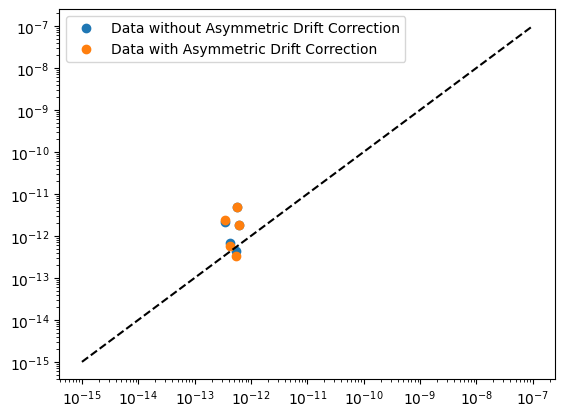

In [10]:
plt.plot(results['mean_acc_bar'], results['mean_acc_obs'], 'o', label='Data without Asymmetric Drift Correction')
plt.plot(results['mean_acc_bar'], results['g_obs'], 'o', label='Data with Asymmetric Drift Correction')
plt.xscale('log')
plt.yscale('log')
plt.legend()
x = np.logspace(-15, -7, 100) 
y = x
plt.plot(x, y, 'k--', label='1:1 Line')
#plt.xlim(1e-12, 1e-7)
#plt.ylim(1e-12, 1e-7)
plt.show()

In [11]:
directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/'

gal = 848

stars_files = []
for filename in glob.glob(os.path.join(directory, '*star*_' + str(gal) + '.hdf5')):
    stars_files.append(filename)

dm_files = []
for filename in glob.glob(os.path.join(directory, '*dm*_' + str(gal) + '.hdf5')):
    dm_files.append(filename)


directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/gas_files/'

gas_files = glob.glob(os.path.join(directory, '*_' + str(gal) + '.hdf5'))


stars_files.sort()
dm_files.sort()
gas_files.sort()

print(len(stars_files))

1


/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/stars_gal_848.hdf5
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/dm_gal_848.hdf5


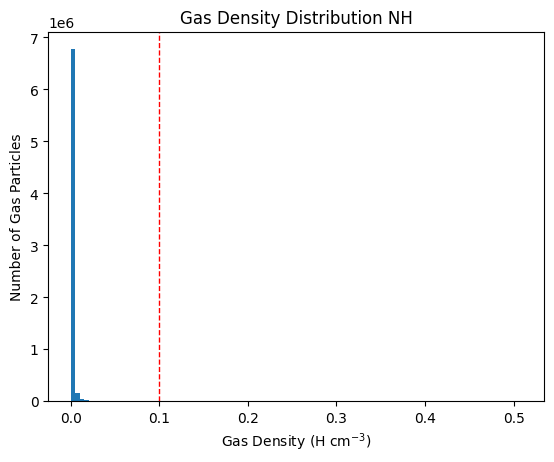

Gas positions shape: (7057960, 3)
H1 positions shape: (19321, 3)


In [12]:


from dynamics import load_all_data

star_filename = stars_files[0]
dm_filename = dm_files[0]
print(star_filename)
print(dm_filename)
gas_filename = gas_files[0]

star_data, dm_data, gas_data, mass_multiplier, length_multiplier, time_multiplier = load_all_data(star_filename, dm_filename, gas_filename, ozy_file)

gas_positions = np.column_stack((gas_data['x'], gas_data['y'], gas_data['z']))
gas_velocities = np.column_stack((gas_data['vx'], gas_data['vy'], gas_data['vz']))
gas_masses = gas_data['mass']

gas_densities = gas_data['density']

H1_positions = np.column_stack((gas_data['h1_x'], gas_data['h1_y'], gas_data['h1_z']))

Msun_to_H = 1.989e30/1.67e-27
kpc_to_cm = 3.086e21

gas_densities = gas_densities * Msun_to_H / kpc_to_cm**3
plt.hist(gas_densities, bins=100)
plt.axvline(0.1, color='r', linestyle='dashed', linewidth=1)
plt.xlabel('Gas Density (H cm$^{-3}$)')
plt.ylabel('Number of Gas Particles')
plt.title('Gas Density Distribution NH')
plt.show()


Msun = 1.989e30
kpc_to_m = 3.086e19
kpc_to_km = 3.086e16

print('Gas positions shape:', gas_positions.shape)
print('H1 positions shape:', H1_positions.shape)



In [13]:

xdata = star_data['x'].value
ydata = star_data['y'].value
zdata = star_data['z'].value

vxdata = star_data['vx'].value
vydata = star_data['vy'].value
vzdata = star_data['vz'].value

massdata = star_data['mass'].value

total_mass = np.sum(massdata)
print('Total mass of the galaxy is: ', total_mass)
#DM data

dm_xdata = dm_data['x'].value
dm_ydata = dm_data['y'].value
dm_zdata = dm_data['z'].value

dm_vxdata = dm_data['vx'].value
dm_vydata = dm_data['vy'].value
dm_vzdata = dm_data['vz'].value

dm_massdata = dm_data['mass'].value

#Calculate the distance from the centre of the galaxy

rdata = np.sqrt(xdata**2 + ydata**2 + zdata**2)
dm_rdata = np.sqrt(dm_xdata**2 + dm_ydata**2 + dm_zdata**2)

points = np.column_stack((xdata, ydata, zdata))
dm_points = np.column_stack((dm_xdata, dm_ydata, dm_zdata))

velocities = np.column_stack((vxdata, vydata, vzdata))
dm_velocities = np.column_stack((dm_vxdata, dm_vydata, dm_vzdata))



Total mass of the galaxy is:  1736971.2285659688


DM centre of mass:  -1.4074980807628832 0.576153421687152 -1.2135080933677407
Star centre of mass:  9.036049686272918e-12 -6.281856979040157e-12 1.225430867890509e-11


<Figure size 640x480 with 0 Axes>

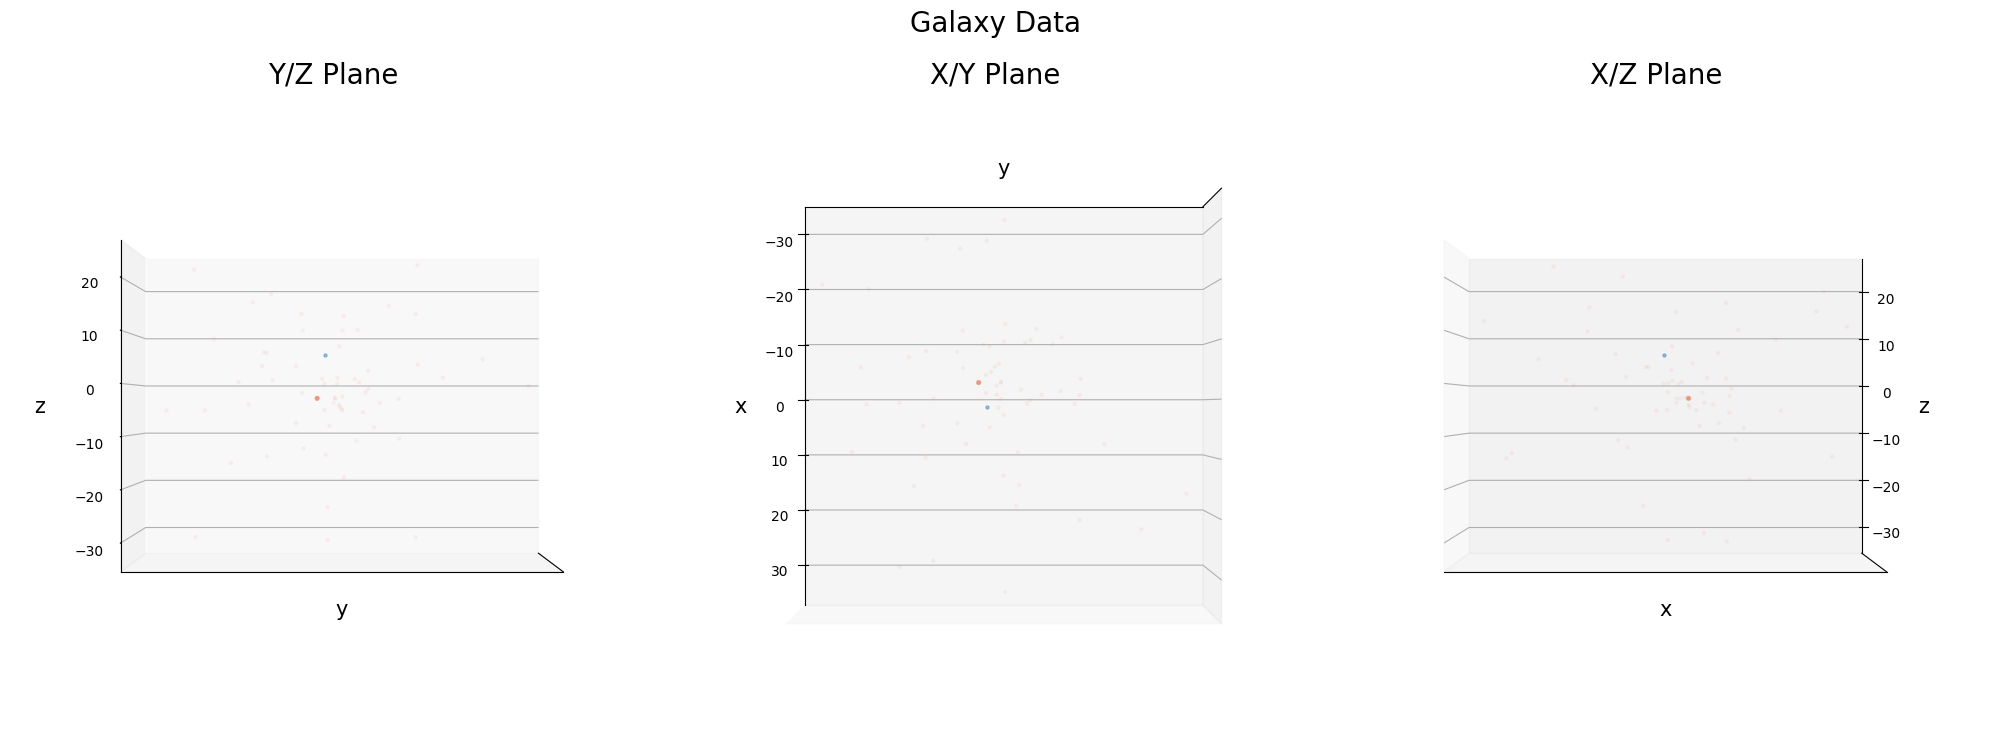

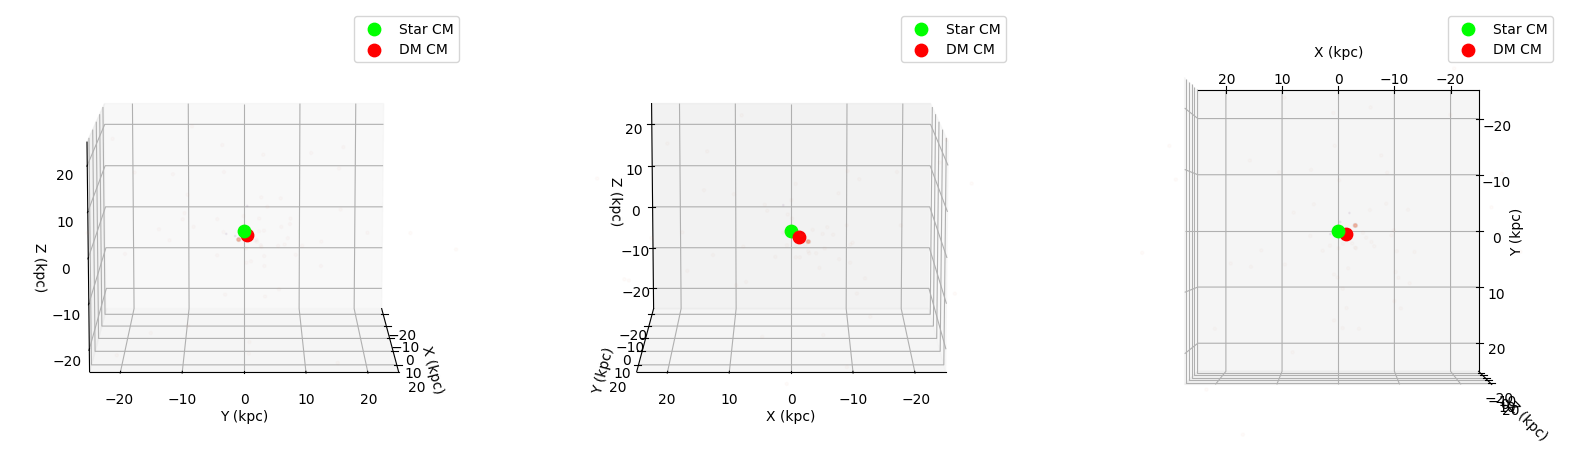

<Figure size 640x480 with 0 Axes>

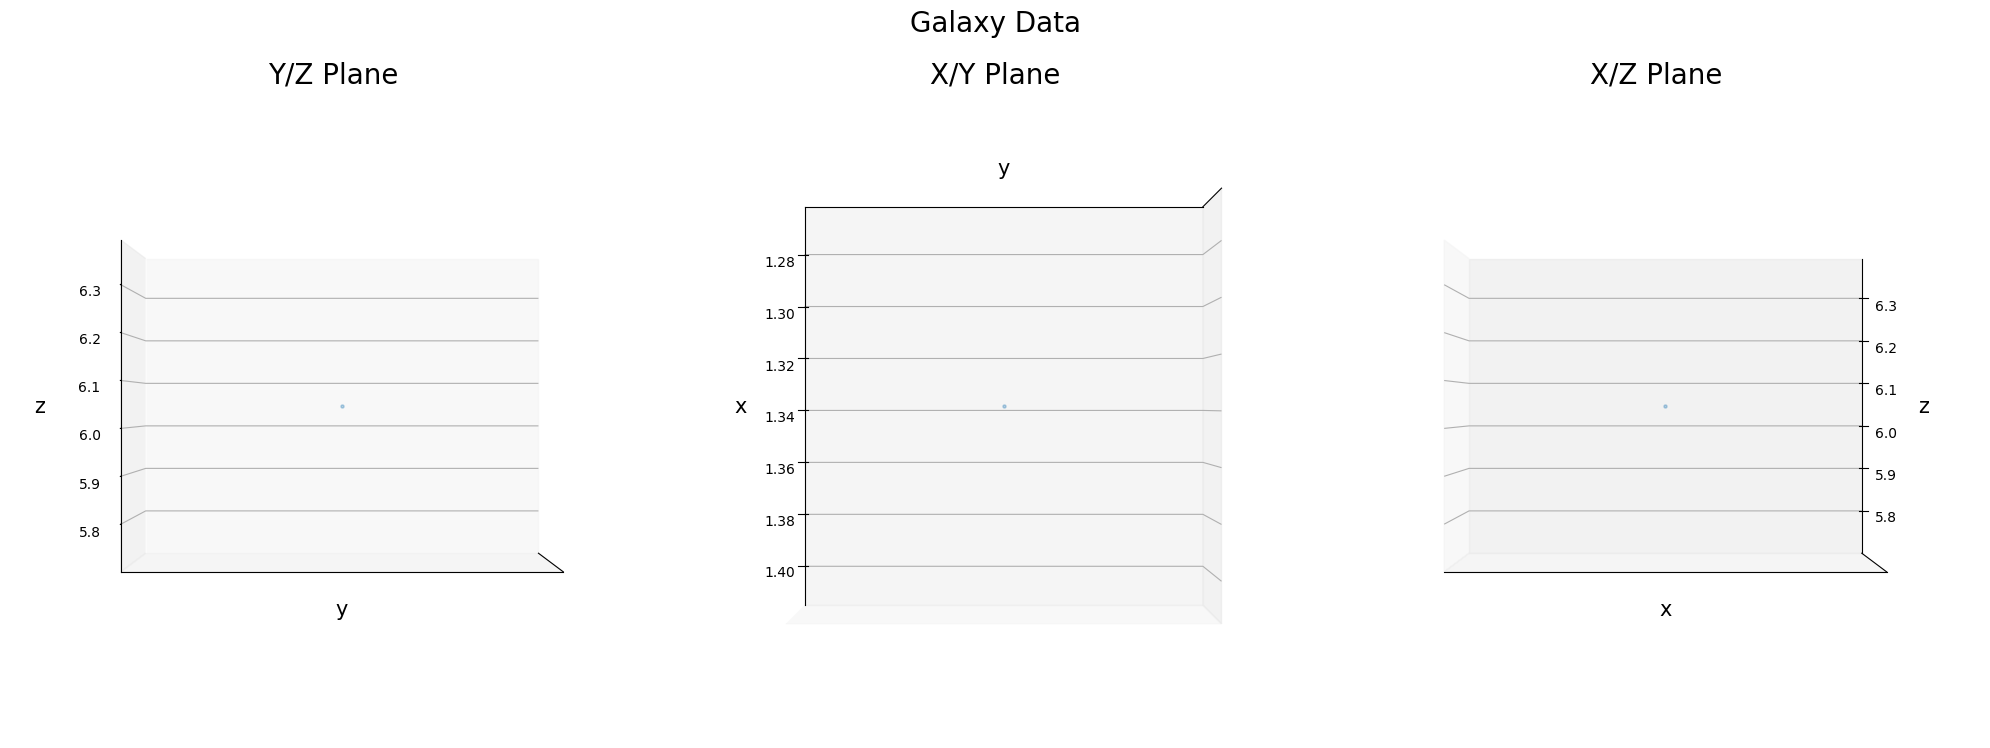

In [14]:
from dynamics import Plot_3d_scatter_with_dm
from dynamics import Plot_3d_scatter

dm_x_cm = np.sum((dm_xdata * dm_massdata)/(np.sum(dm_massdata)))
dm_y_cm = np.sum((dm_ydata * dm_massdata)/(np.sum(dm_massdata)))
dm_z_cm = np.sum((dm_zdata * dm_massdata)/(np.sum(dm_massdata)))

print('DM centre of mass: ', dm_x_cm, dm_y_cm, dm_z_cm)

star_x_cm = np.sum((xdata * massdata)/(np.sum(massdata)))
star_y_cm = np.sum((ydata * massdata)/(np.sum(massdata)))
star_z_cm = np.sum((zdata * massdata)/(np.sum(massdata)))

print('Star centre of mass: ', star_x_cm, star_y_cm, star_z_cm)

Plot_3d_scatter_with_dm(xdata, ydata, zdata, dm_xdata, dm_ydata, dm_zdata, 'x', 'y', 'z', 'Galaxy Data')




fig, (ax1, ax2, ax3) = plt.subplots(1, 3, subplot_kw={'projection': '3d'}, figsize=(20, 8))

ax1.scatter(xdata[::100], ydata[::100], zdata[::100], c = np.log10(massdata[::100]), alpha = 0.05, s = 1)
ax1.scatter(dm_xdata[::100], dm_ydata[::100], dm_zdata[::100], marker='.', alpha=0.03, color = 'darksalmon')
ax1.scatter(star_x_cm, star_y_cm, star_z_cm, marker='o', color='lime', s=80, label='Star CM')
ax1.scatter(dm_x_cm, dm_y_cm, dm_z_cm, marker='o', color='red', s=80, label='DM CM')
ax1.set_xlim(-25,25)
ax1.set_xlabel('X (kpc)')
ax1.set_ylim(-25,25)
ax1.set_ylabel('Y (kpc)')
ax1.set_zlim(-25,25)
ax1.set_zlabel('Z (kpc)')
ax1.legend()


ax1.view_init(elev=10, azim=0)


ax2.scatter(xdata[::100], ydata[::100], zdata[::100], c = np.log10(massdata[::100]), alpha = 0.05, s = 1)
ax2.scatter(dm_xdata[::100], dm_ydata[::100], dm_zdata[::100], marker='.', alpha=0.03, color = 'darksalmon')
ax2.scatter(star_x_cm, star_y_cm, star_z_cm, marker='o', color='lime', s=80, label='Star CM')
ax2.scatter(dm_x_cm, dm_y_cm, dm_z_cm, marker='o', color='red', s=80, label='DM CM')
ax2.set_xlim(-25,25)
ax2.set_xlabel('X (kpc)')
ax2.set_ylim(-25,25)
ax2.set_ylabel('Y (kpc)')
ax2.set_zlim(-25,25)
ax2.set_zlabel('Z (kpc)')
ax2.legend()
ax2.view_init(elev=10, azim=90)


ax3.scatter(xdata[::100], ydata[::100], zdata[::100], c = np.log10(massdata[::100]), alpha = 0.05, s = 1)
ax3.scatter(dm_xdata[::100], dm_ydata[::100], dm_zdata[::100], marker='.', alpha=0.03, color = 'darksalmon')
ax3.scatter(star_x_cm, star_y_cm, star_z_cm, marker='o', color='lime', s=80, label='Star CM')
ax3.scatter(dm_x_cm, dm_y_cm, dm_z_cm, marker='o', color='red', s=80, label='DM CM')
ax3.set_xlim(-25,25)
ax3.set_xlabel('X (kpc)')
ax3.set_ylim(-25,25)
ax3.set_ylabel('Y (kpc)')
ax3.set_zlim(-25,25)
ax3.set_zlabel('Z (kpc)')
ax3.legend()

ax3.view_init(elev=90, azim=90)

plt.show()

Plot_3d_scatter(xdata, ydata, zdata, 'x', 'y', 'z', 'Galaxy Data')




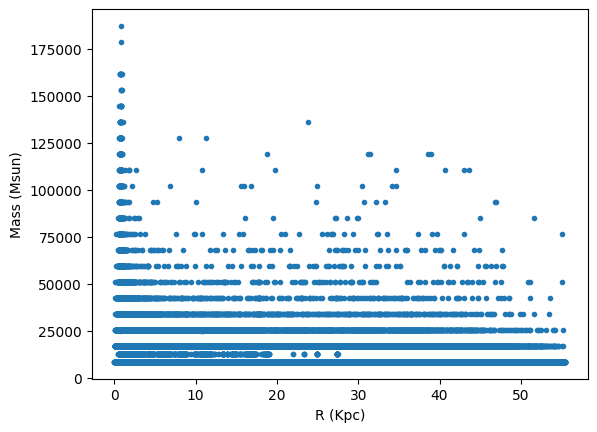

In [7]:
plt.plot(rdata, massdata, '.')
plt.xlabel('R (Kpc)')
plt.ylabel('Mass (Msun)')
plt.show()


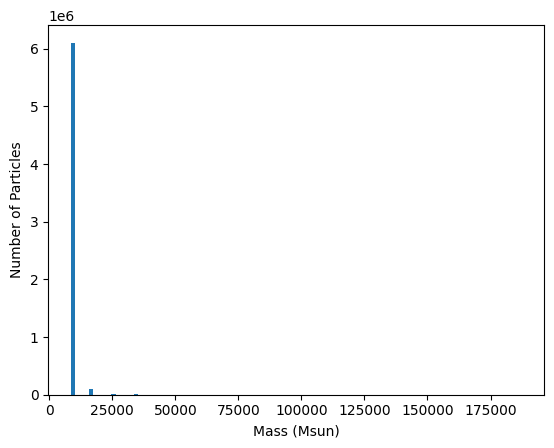

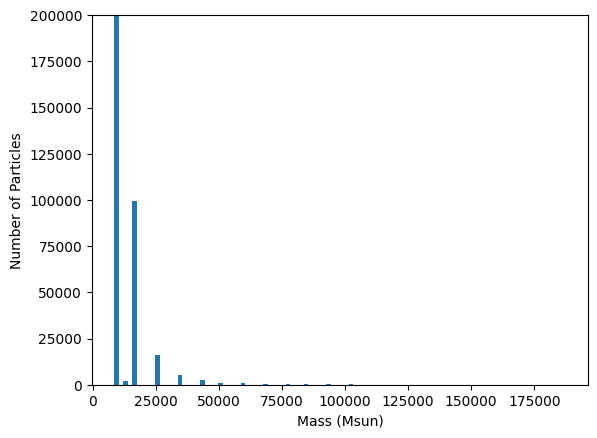

In [8]:
plt.hist(massdata, bins=100)
plt.xlabel('Mass (Msun)')
plt.ylabel('Number of Particles')
plt.show()


plt.hist(massdata, bins=100)
plt.ylim(0, 200000)
plt.xlabel('Mass (Msun)')
plt.ylabel('Number of Particles')
plt.show()

In [9]:
#Sort the data by distance from the centre of the galaxy
#Create an array called mapping which has the final after its sorted in terms of distance, therefore any other data can be sorted in the same way

from dynamics import create_mapping
mapping = create_mapping(rdata)


#The array mapping contains the indicies of the rdata array which are sorted in ascending distance from the centre of the galaxy (rdata[mapping[0]] is the minimum distance)

print(rdata[mapping[0]], rdata[mapping[-1]])

0.009239752637669367 55.47675213454438


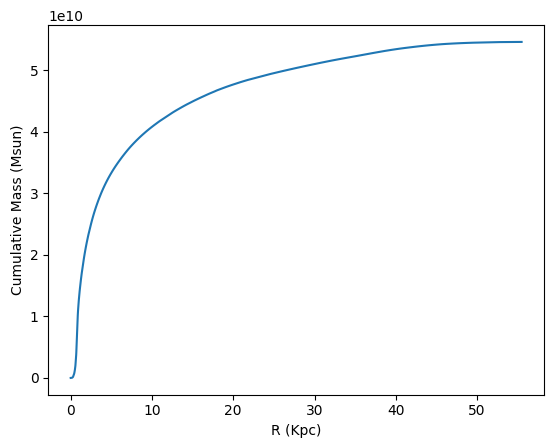

In [10]:
#Now sort the r and mass data in the same way

massdata_sorted = np.array(massdata[mapping])
rdata_sorted = np.array(rdata[mapping])


#Now a cumulative sum of the mass data gives the cumulative sum starting with the particles closest to the centre of the galaxy
cum_mass = np.cumsum(massdata_sorted)
plt.plot(rdata_sorted, cum_mass)
plt.xlabel('R (Kpc)')
plt.ylabel('Cumulative Mass (Msun)')
plt.show()



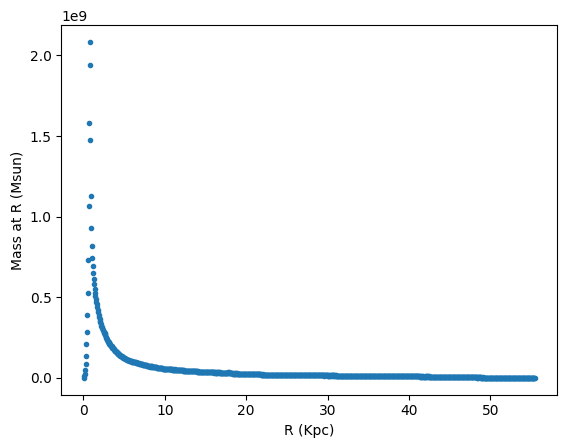

In [11]:
number_of_bins = 1000

max_r = rdata_sorted[-1]
min_r = rdata_sorted[0]
length_of_bins = (max_r - min_r)/number_of_bins

mass_sum = []
meanr = []
densities = []

for i in range(number_of_bins):

    maxr_in_bin = min_r + (i+1)*length_of_bins
    minr_in_bin = min_r + i*length_of_bins

    mask = (rdata_sorted > minr_in_bin) & (rdata_sorted < maxr_in_bin)
    mass_sum.append(np.sum(massdata_sorted[mask]))
    meanr.append(np.mean(rdata_sorted[mask]))

    volume = 4/3*np.pi*(maxr_in_bin)**3 - 4/3*np.pi*(minr_in_bin)**3
    densities.append(np.sum(massdata_sorted[mask])/volume)



plt.plot(meanr, mass_sum, '.')
plt.xlabel('R (Kpc)')
plt.ylabel('Mass at R (Msun)')
plt.show()

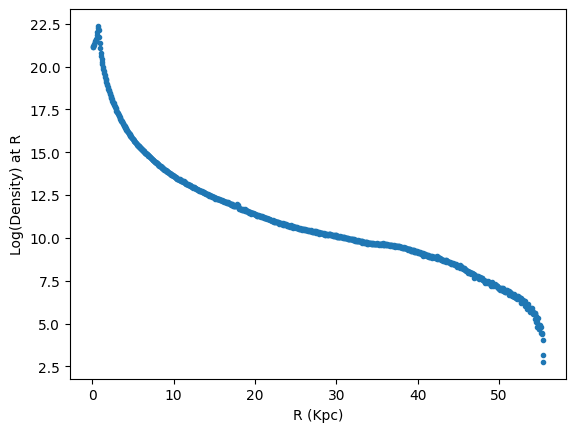

In [12]:
plt.plot(meanr, np.log(densities), '.')
plt.xlabel('R (Kpc)')
plt.ylabel('Log(Density) at R')
plt.show()

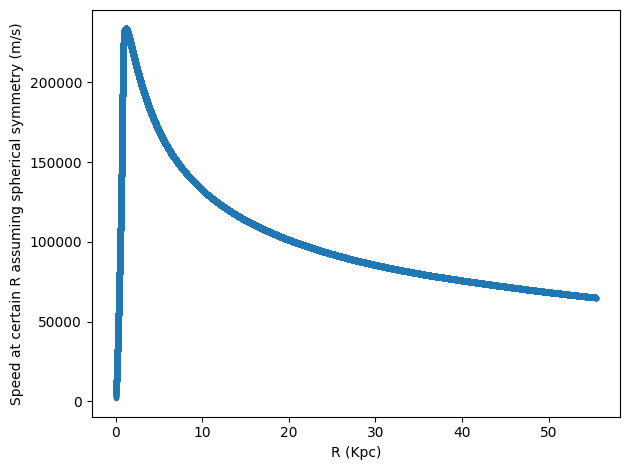

In [13]:
#To calculate speed of one particle given its r vector and mass:
#v = sqrt(GM/r) (where M is the mass of the galaxy which is enclosed by the radius r) (this is assuming spherical symmetry)

speed = np.sqrt(constants.G*cum_mass*Msun/(rdata_sorted*kpc_to_m))
plt.plot(rdata_sorted, speed, '.')
plt.xlabel('R (Kpc)')
plt.ylabel('Speed at certain R assuming spherical symmetry (m/s)')
plt.tight_layout()
plt.show()

[[ 0.89905553 -0.42603022 -0.10098224]
 [-0.42603022 -0.7980355  -0.42618962]
 [ 0.10098224  0.42618962 -0.89897998]]
[[ 0.77234545 -0.61563595 -0.15644448]
 [-0.61563595 -0.66483662 -0.42306577]
 [ 0.15644448  0.42306577 -0.89249116]]


<Figure size 640x480 with 0 Axes>

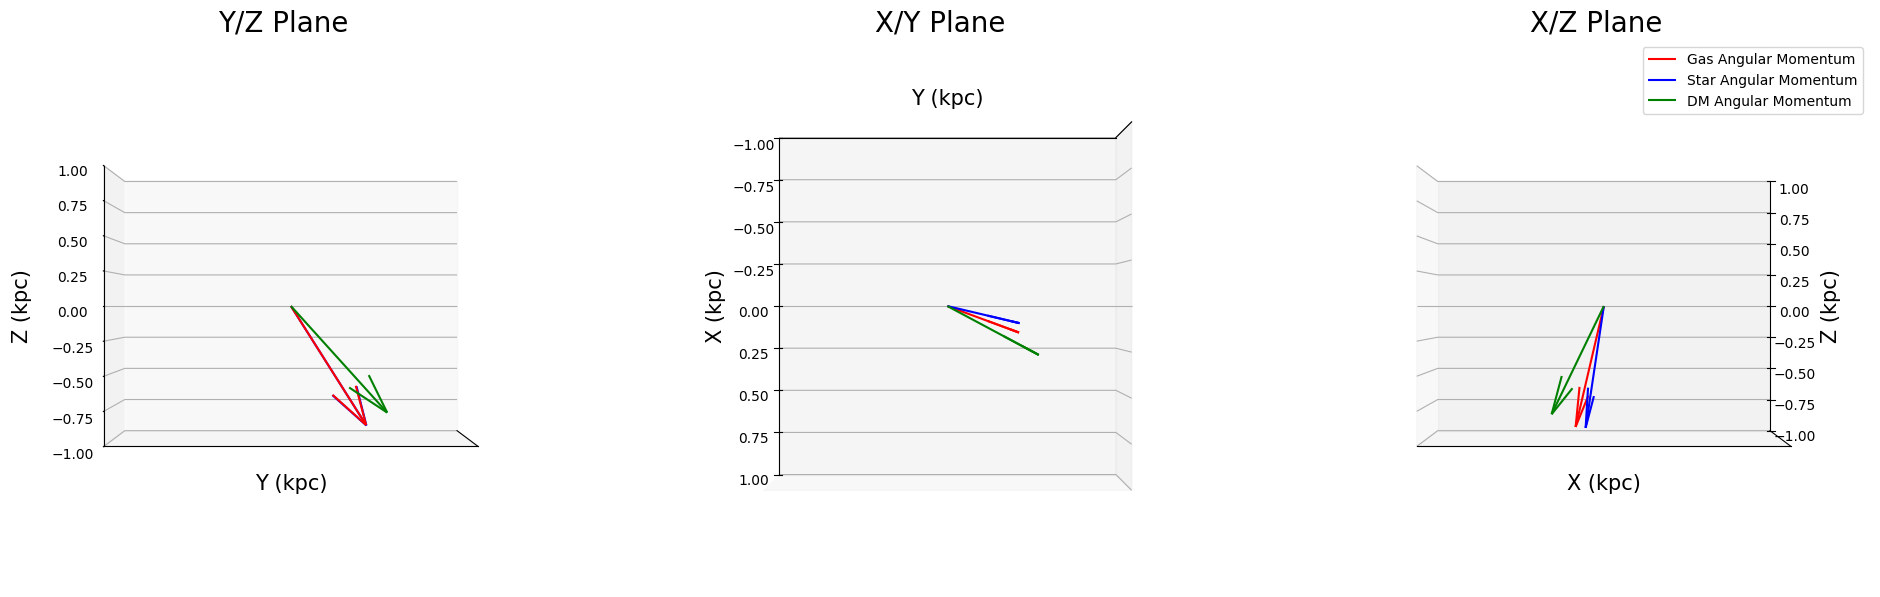

In [14]:
#Calculate total angular momentum of all particles in the simulation

#Angular momentum of one particle is L = r x p
#Or if we remove the mass from p we get L = m * (r x v)
#Then we want to sum up all the L vectors for all particles to get the resulting L of the galaxy

#points = np.column_stack((xdata, ydata, zdata)) (each particles r vector) (sorted by r)
#rdata = np.sqrt(xdata**2 + ydata**2 + zdata**2) (each particles r magnitude)

#Moving into 3d we need to sort the position vectors in terms of their overall distance from the centre of the galaxy

from dynamics import create_rotation_matrix

rotation_matrix = create_rotation_matrix(velocities, points, massdata, False)

rotation_matrix_gas = create_rotation_matrix(gas_velocities, gas_positions, gas_masses, False)

gas_ang_mom = np.cross(gas_positions, gas_velocities * gas_masses[:, np.newaxis])
gas_L_ang = np.sum(gas_ang_mom, axis=0)

star_ang_mom = np.cross(points, velocities * massdata[:, np.newaxis])
total_star_ang_mom = np.sum(star_ang_mom, axis=0)

dm_ang_mom = np.cross(dm_points, dm_velocities * dm_massdata[:, np.newaxis])
total_dm_ang_mom = np.sum(dm_ang_mom, axis=0)

labelx = 'X (kpc)'
labely = 'Y (kpc)'
labelz = 'Z (kpc)'

fig = plt.figure()
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, subplot_kw={'projection': '3d'}, figsize=(24, 8))

ax1.quiver(0,0,0, gas_L_ang[0], gas_L_ang[1], gas_L_ang[2], color='r', length=1, normalize=True, label='Gas Angular Momentum')
ax1.quiver(0,0,0, total_star_ang_mom[0], total_star_ang_mom[1], total_star_ang_mom[2], color='b', length=1, normalize=True, label='Star Angular Momentum')
ax1.quiver(0,0,0, total_dm_ang_mom[0], total_dm_ang_mom[1], total_dm_ang_mom[2], color='g', length=1, normalize=True, label='DM Angular Momentum')
ax1.view_init(elev=0, azim=0) 
ax1.set_ylabel(labely, size=15)
ax1.set_zlabel(labelz, size=15)
ax1.set_title('Y/Z Plane', size=20)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.tick_params(axis='z', pad=8)
ax1.zaxis.labelpad = 20
ax1.set_xlim(-1,1)
ax1.set_ylim(-1,1)
ax1.set_zlim(-1,1)



ax2.quiver(0,0,0, gas_L_ang[0], gas_L_ang[1], gas_L_ang[2], color='r', length=1, normalize=True, label='Gas Angular Momentum')
ax2.quiver(0,0,0, total_star_ang_mom[0], total_star_ang_mom[1], total_star_ang_mom[2], color='b', length=1, normalize=True, label='Star Angular Momentum')
ax2.quiver(0,0,0, total_dm_ang_mom[0], total_dm_ang_mom[1], total_dm_ang_mom[2], color='g', length=1, normalize=True, label='DM Angular Momentum')
ax2.view_init(elev=90, azim=0) 
ax2.set_xlabel(labelx, size=15)
ax2.set_ylabel(labely, size=15)
ax2.set_title('X/Y Plane', size=20)
ax2.set_zticks([])
ax2.set_yticks([])
ax2.tick_params(axis='x', pad=8)
ax2.xaxis.labelpad = 20
ax2.set_xlim(-1,1)
ax2.set_ylim(-1,1)
ax2.set_zlim(-1,1)




ax3.quiver(0,0,0, gas_L_ang[0], gas_L_ang[1], gas_L_ang[2], color='r', length=1, normalize=True, label='Gas Angular Momentum')
ax3.quiver(0,0,0, total_star_ang_mom[0], total_star_ang_mom[1], total_star_ang_mom[2], color='b', length=1, normalize=True, label='Star Angular Momentum')
ax3.quiver(0,0,0, total_dm_ang_mom[0], total_dm_ang_mom[1], total_dm_ang_mom[2], color='g', length=1, normalize=True, label='DM Angular Momentum')
ax3.view_init(elev=0, azim=90)
ax3.set_xlabel(labelx, size=15)
ax3.set_zlabel(labelz, size=15)
ax3.set_title('X/Z Plane', size=20)
ax3.set_yticks([])
ax3.set_xticks([])
ax3.tick_params(axis='z', pad=8)
ax3.zaxis.labelpad = 20
ax3.set_xlim(-1,1)
ax3.set_ylim(-1,1)
ax3.set_zlim(-1,1)

plt.legend()

plt.show()


In [15]:
#Now apply the rotation matrix to the velocity vectors

velocities_rotated = np.dot(rotation_matrix, velocities.T).T
rotated_points = np.dot(rotation_matrix, points.T).T

rotated_gas_velocities = np.dot(rotation_matrix_gas, gas_velocities.T).T
rotated_gas_points = np.dot(rotation_matrix_gas, gas_positions.T).T

print(len(rotated_gas_points))
print(len(rotated_points))

velocities_rotated = np.append(velocities_rotated, rotated_gas_velocities.value, axis=0)
rotated_points = np.append(rotated_points, rotated_gas_points, axis=0)

print(len(rotated_points))
massdata = np.append(massdata, gas_masses.value, axis=0)
rdata = np.append(rdata, np.sqrt(gas_positions[:,0]**2 + gas_positions[:,1]**2 + gas_positions[:,2]**2))


velocities_rotated_dm = np.dot(rotation_matrix, dm_velocities.T).T
rotated_points_dm = np.dot(rotation_matrix, dm_points.T).T


7905125
6232734
14137859


<Figure size 640x480 with 0 Axes>

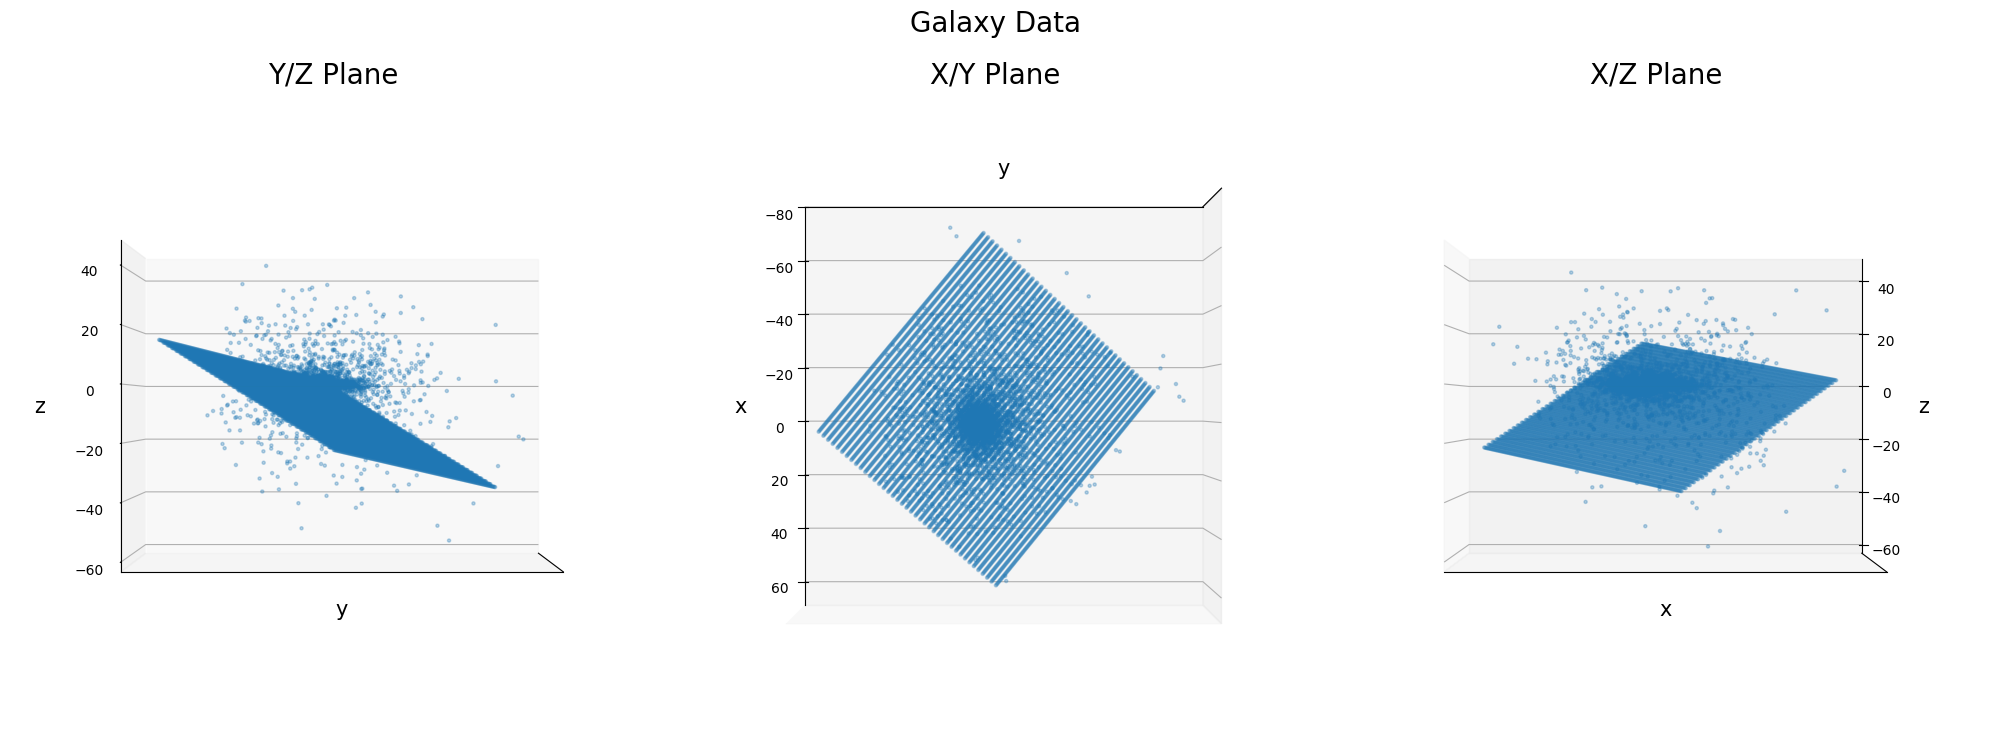

<Figure size 640x480 with 0 Axes>

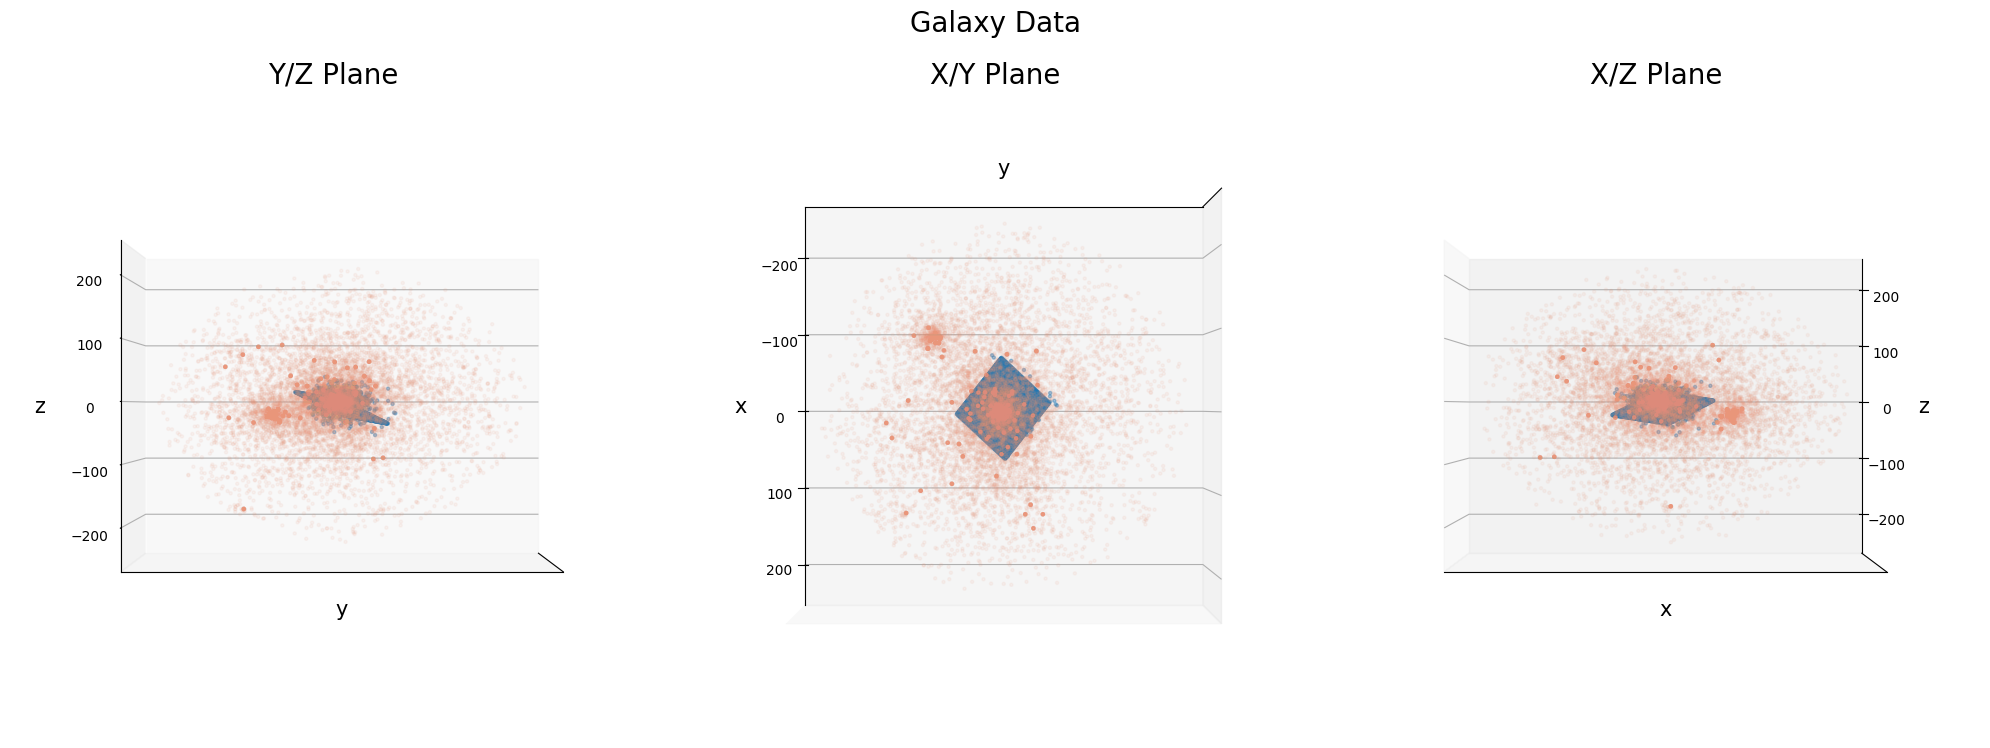

In [16]:

Plot_3d_scatter(rotated_points[:,0], rotated_points[:,1], rotated_points[:,2], 'x', 'y', 'z', 'Galaxy Data')

Plot_3d_scatter_with_dm(rotated_points[:,0], rotated_points[:,1], rotated_points[:,2], rotated_points_dm[:,0], rotated_points_dm[:,1], rotated_points_dm[:,2], 'x', 'y', 'z', 'Galaxy Data')




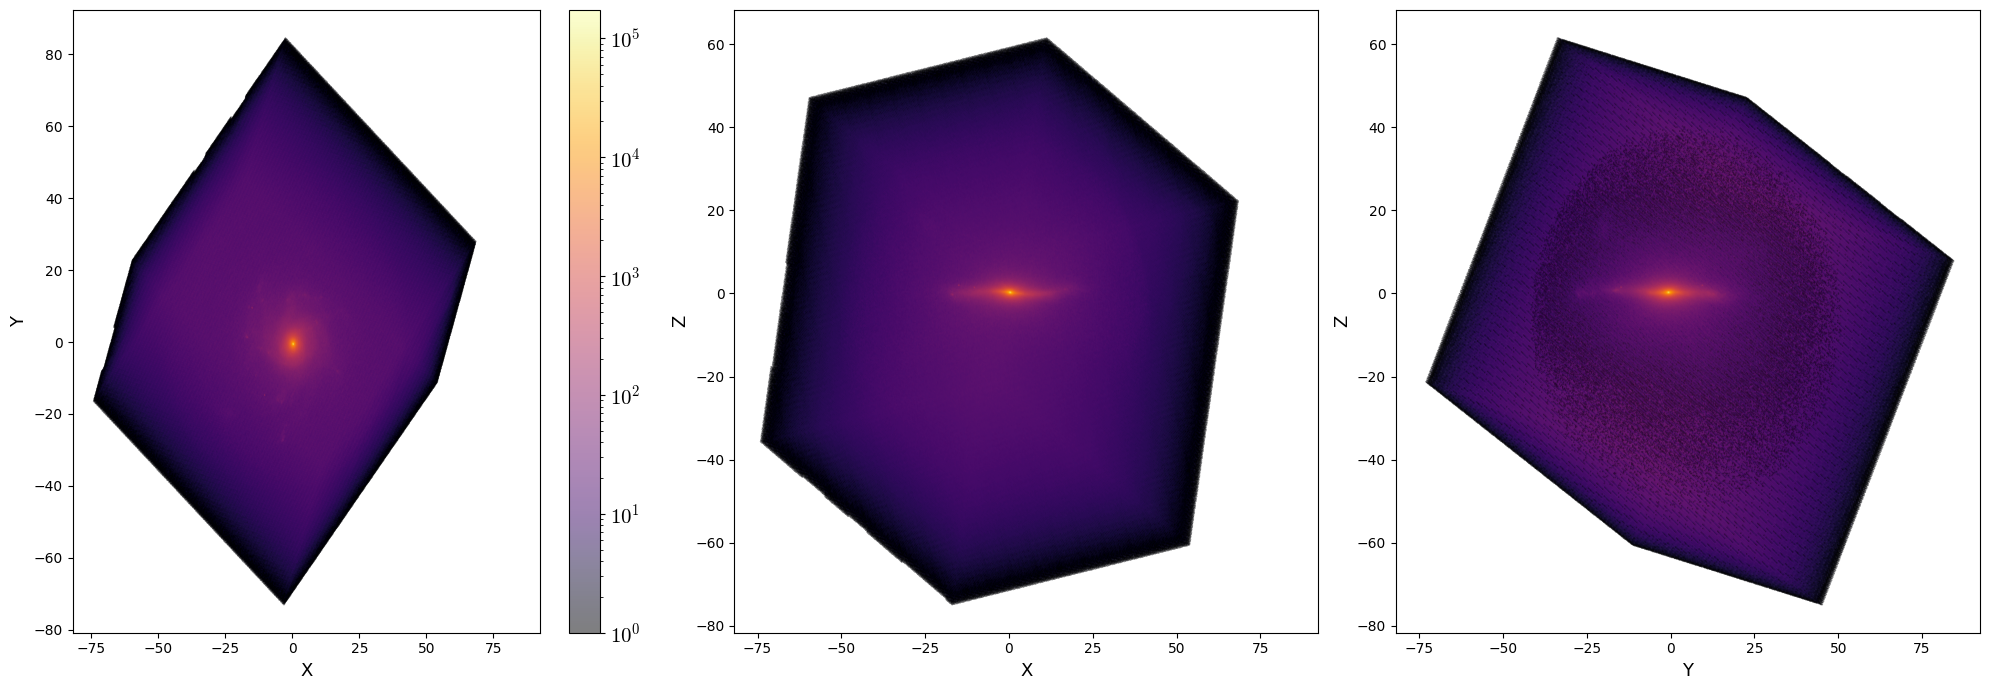

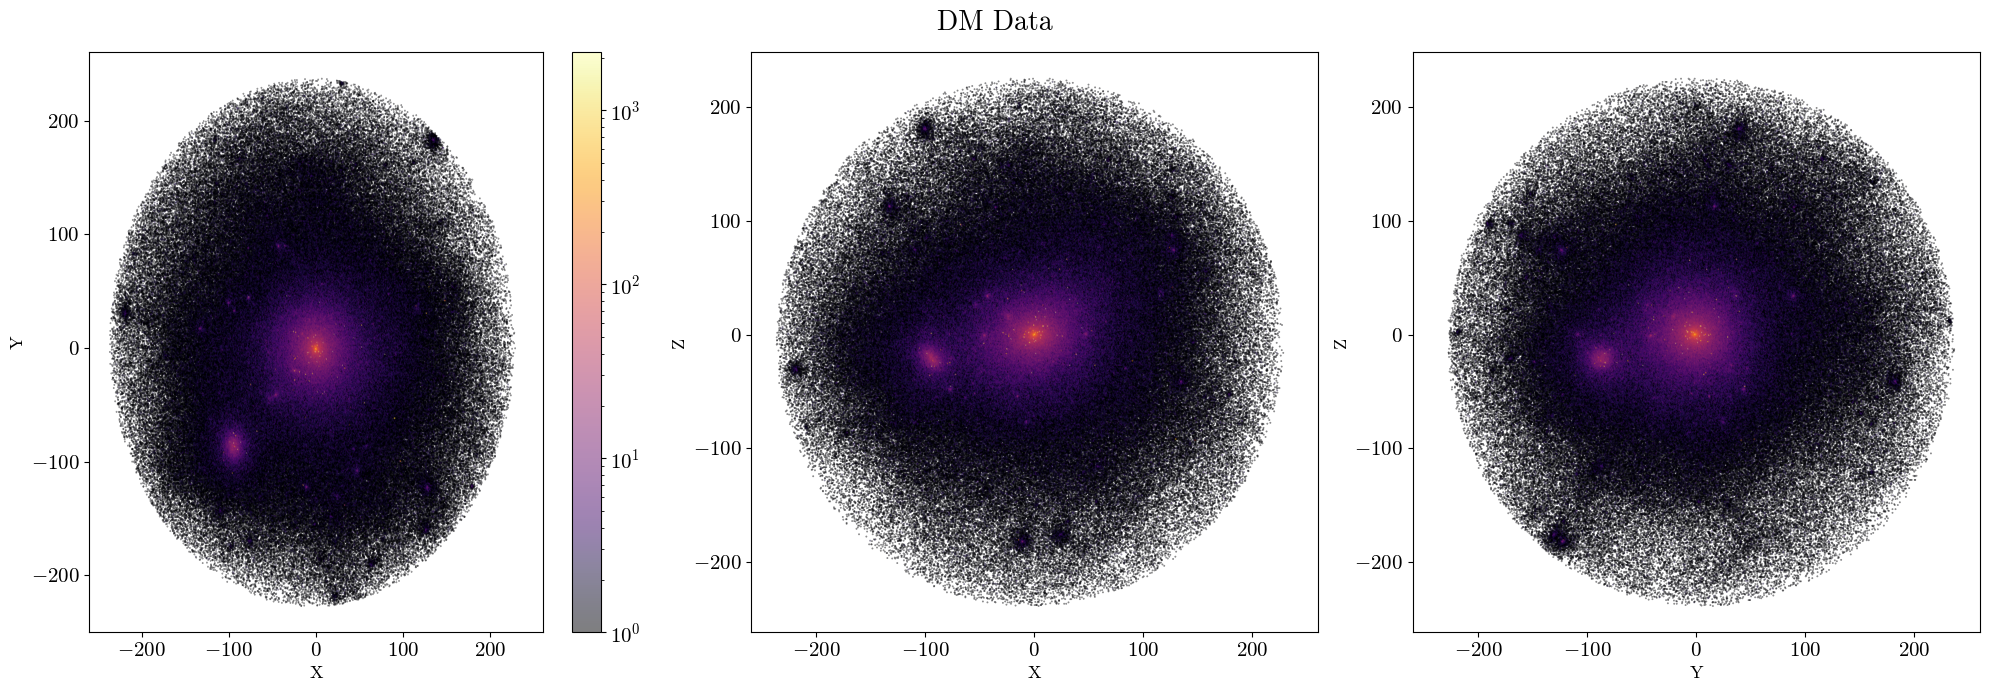

In [17]:
figure, axis = plt.subplots(1,3, sharex=True, figsize=(20, 7))

plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['font.family'] = 'cmr10'  # Computer Modern Roman
plt.rcParams["xtick.labelsize"] = 15   # Increase x-axis tick font size
plt.rcParams["ytick.labelsize"] = 15   # Increase y-axis tick font size


axis[0].hexbin(rotated_points[:,0], rotated_points[:,1], alpha = 0.5, gridsize = 1000, cmap = 'inferno', bins = 'log')
axis[1].hexbin(rotated_points[:,0], rotated_points[:,2], alpha = 0.5, gridsize = 1000, cmap = 'inferno', bins = 'log')
axis[2].hexbin(rotated_points[:,1], rotated_points[:,2], alpha = 0.5, gridsize = 1000, cmap = 'inferno', bins = 'log')

axis[0].set_xlabel('X', fontsize = 13)
axis[0].set_ylabel('Y', fontsize = 13)
axis[1].set_xlabel('X', fontsize = 13)
axis[1].set_ylabel('Z', fontsize = 13)
axis[2].set_xlabel('Y', fontsize = 13)
axis[2].set_ylabel('Z', fontsize = 13)

plt.colorbar(axis[0].collections[0], ax=axis[0])

plt.tight_layout()

plt.show()

#SAME FOR DM

figure, axis = plt.subplots(1,3, sharex=True, figsize=(20, 7))

plt.suptitle('DM Data', fontsize=20)

plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['font.family'] = 'cmr10'  # Computer Modern Roman
plt.rcParams["xtick.labelsize"] = 15   # Increase x-axis tick font size
plt.rcParams["ytick.labelsize"] = 15   # Increase y-axis tick font size


axis[0].hexbin(rotated_points_dm[:,0], rotated_points_dm[:,1], alpha = 0.5, gridsize = 1000, cmap = 'inferno', bins = 'log')
axis[1].hexbin(rotated_points_dm[:,0], rotated_points_dm[:,2], alpha = 0.5, gridsize = 1000, cmap = 'inferno', bins = 'log')
axis[2].hexbin(rotated_points_dm[:,1], rotated_points_dm[:,2], alpha = 0.5, gridsize = 1000, cmap = 'inferno', bins = 'log')

axis[0].set_xlabel('X', fontsize = 13)
axis[0].set_ylabel('Y', fontsize = 13)
axis[1].set_xlabel('X', fontsize = 13)
axis[1].set_ylabel('Z', fontsize = 13)
axis[2].set_xlabel('Y', fontsize = 13)
axis[2].set_ylabel('Z', fontsize = 13)

plt.colorbar(axis[0].collections[0], ax=axis[0])

plt.tight_layout()

plt.show()

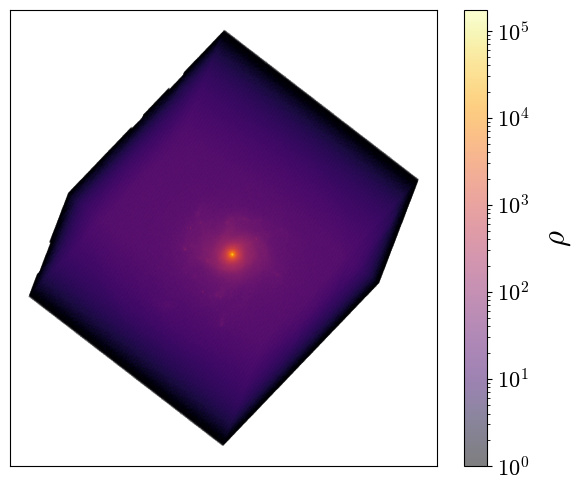

In [18]:


plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['font.family'] = 'cmr10'  # Computer Modern Roman
plt.rcParams["xtick.labelsize"] = 16   # Increase x-axis tick font size
plt.rcParams["ytick.labelsize"] = 16   # Increase y-axis tick font size

plt.figure(figsize=(6, 5))

plt.hexbin(rotated_points[:,0], rotated_points[:,1], alpha = 0.5, gridsize = 1000, cmap = 'inferno', bins = 'log')
plt.xticks([])
plt.yticks([])

cbar = plt.colorbar()
cbar.set_label(r"$\rho$", labelpad=12, fontsize = 22)

plt.tight_layout()

plt.show()

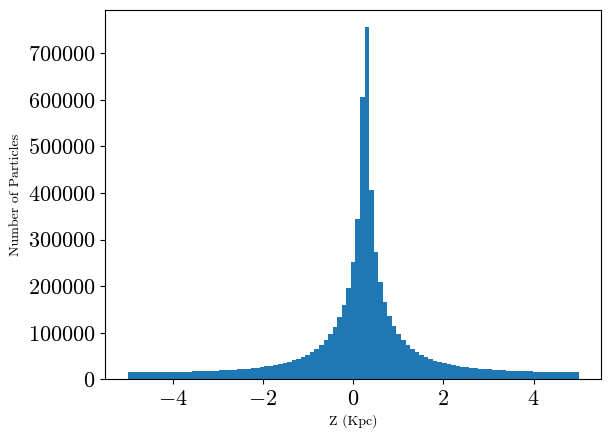

In [19]:
#Get a rough idea for the width of the galaxy

plt.hist(rotated_points[:,2], bins = np.linspace(-5,5, 100))
plt.xlabel('Z (Kpc)')
plt.ylabel('Number of Particles')
plt.show()

<Figure size 640x480 with 0 Axes>

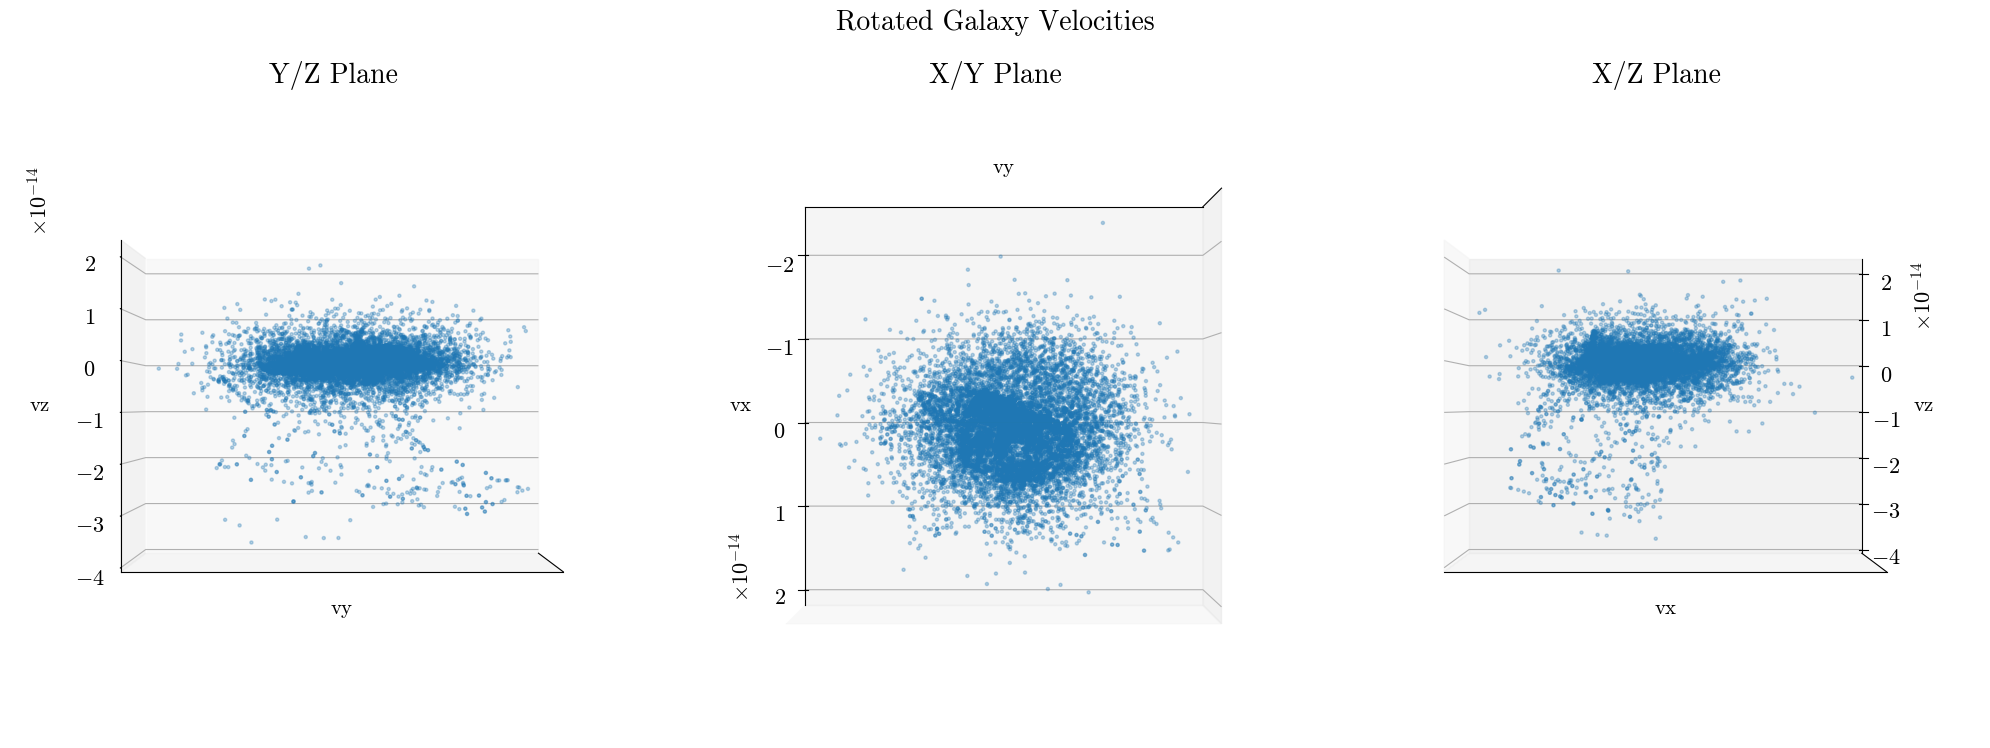

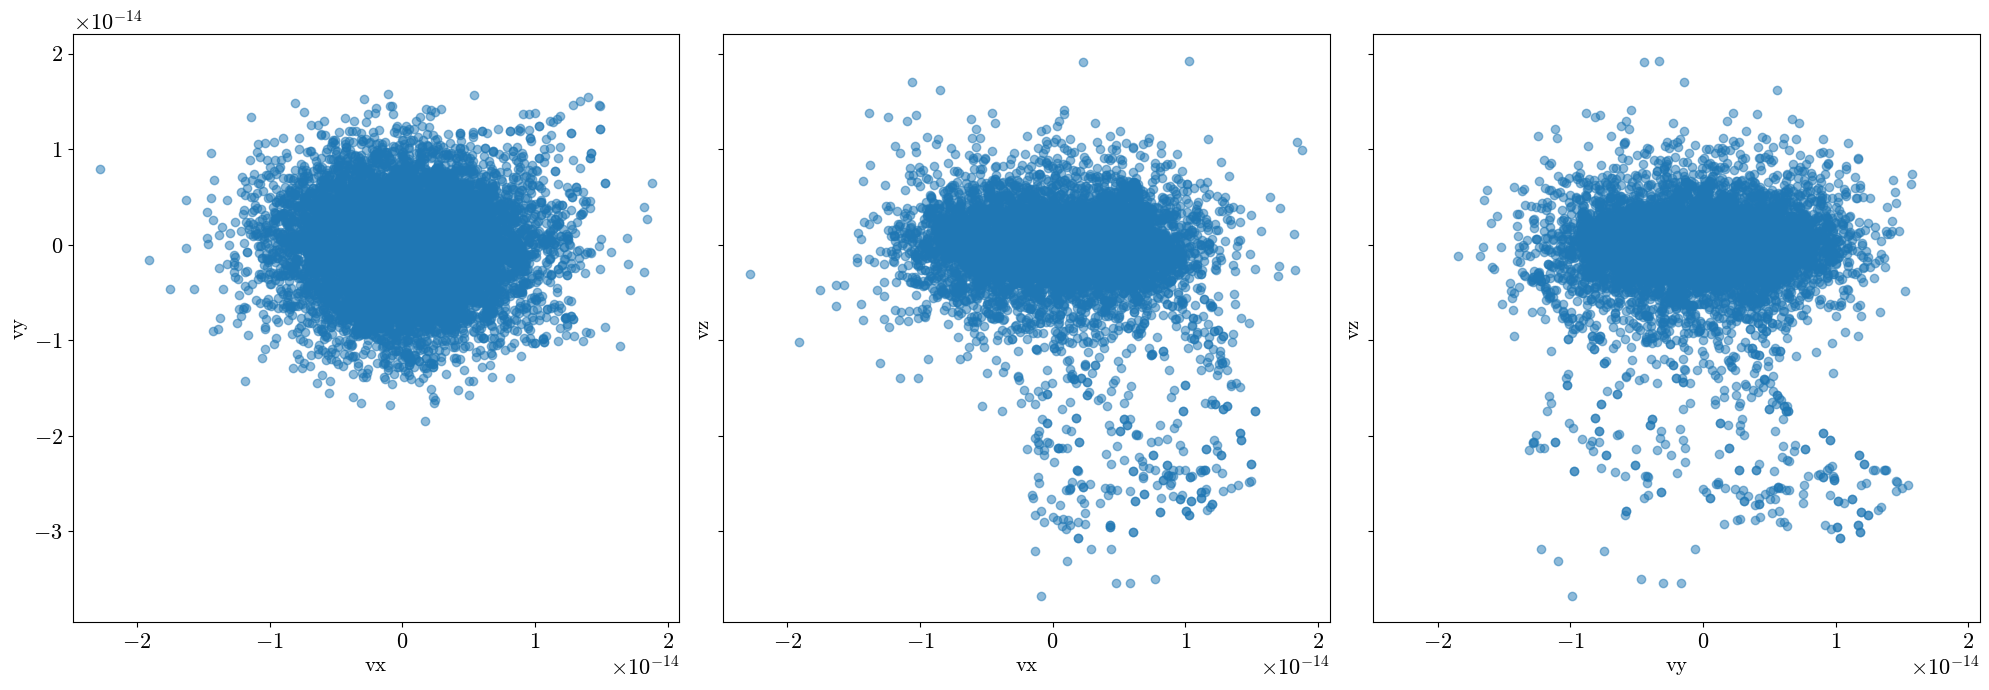

In [20]:
#Plot new rotated velocities on a 3d scatter plot

Plot_3d_scatter(velocities_rotated[:,0], velocities_rotated[:,1], velocities_rotated[:,2], 'vx', 'vy', 'vz', 'Rotated Galaxy Velocities')

fig, ax = plt.subplots(1,3, figsize=(20, 7), sharex=True, sharey=True)

ax[0].scatter(velocities_rotated[:,0][::1000], velocities_rotated[:,1][::1000], alpha = 0.5)
ax[0].set_xlabel('vx', fontsize = 15)
ax[0].set_ylabel('vy', fontsize = 15)

ax[1].scatter(velocities_rotated[:,0][::1000], velocities_rotated[:,2][::1000], alpha = 0.5)
ax[1].set_xlabel('vx', fontsize = 15)
ax[1].set_ylabel('vz', fontsize = 15)

ax[2].scatter(velocities_rotated[:,1][::1000], velocities_rotated[:,2][::1000], alpha = 0.5)
ax[2].set_xlabel('vy', fontsize = 15)
ax[2].set_ylabel('vz', fontsize = 15)

plt.tight_layout()
plt.show()





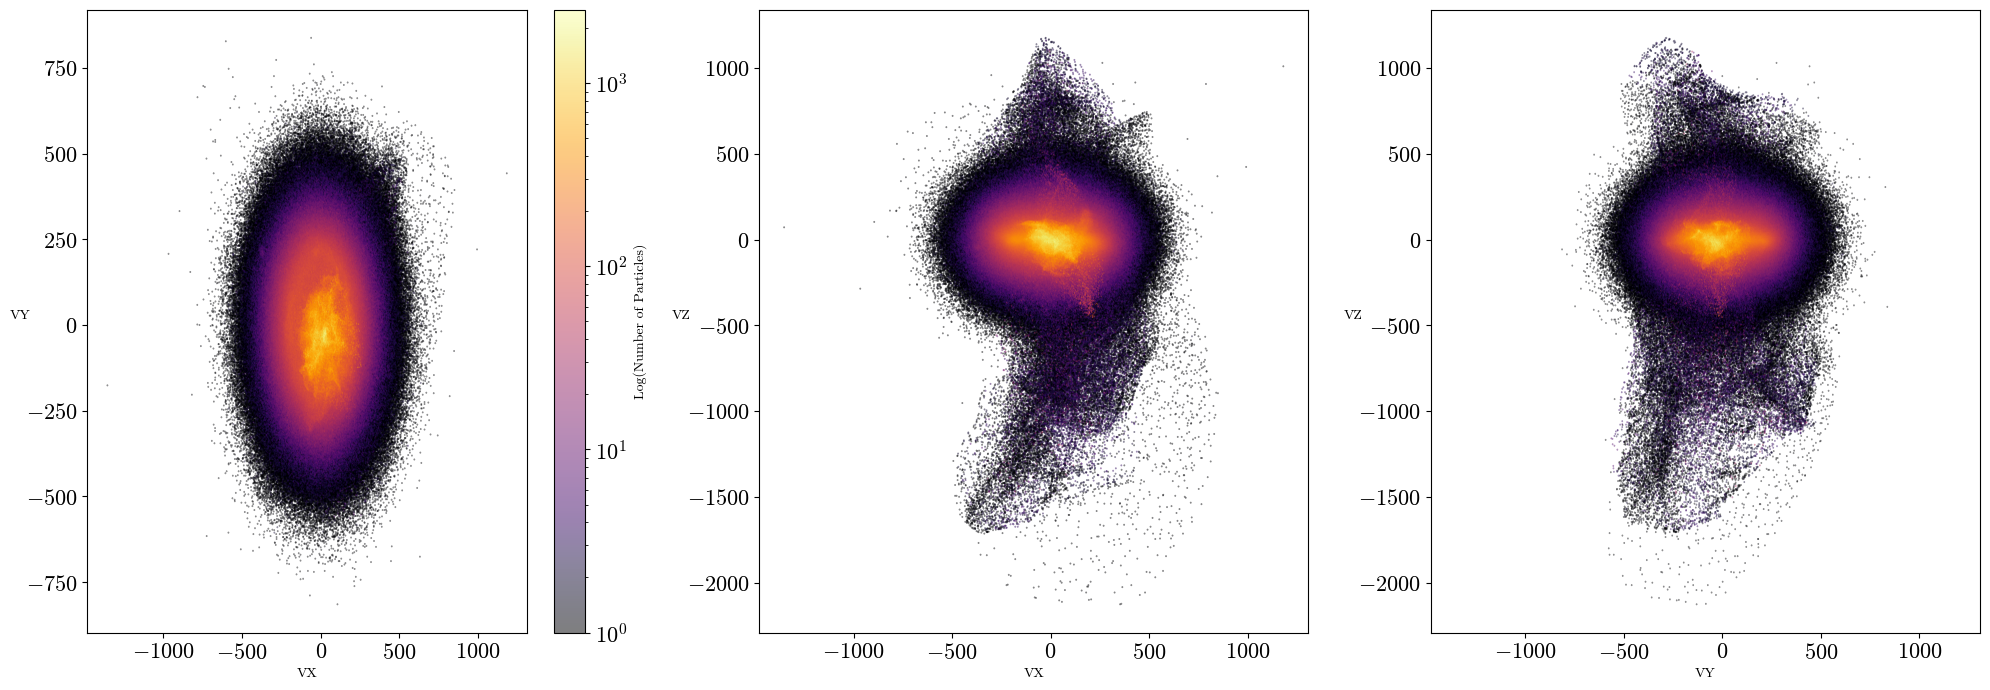

In [21]:
#Plot rotated velocities as a hexbin rather than a scatter

figure, axis = plt.subplots(1,3, sharex=True, figsize=(20, 7))

axis[0].hexbin(velocities_rotated[:,0]*kpc_to_m/1000, velocities_rotated[:,1]*kpc_to_m/1000, alpha = 0.5, gridsize = 1000, cmap = 'inferno', bins = 'log')
axis[1].hexbin(velocities_rotated[:,0]*kpc_to_m/1000, velocities_rotated[:,2]*kpc_to_m/1000, alpha = 0.5, gridsize = 1000, cmap = 'inferno', bins = 'log')
axis[2].hexbin(velocities_rotated[:,1]*kpc_to_m/1000, velocities_rotated[:,2]*kpc_to_m/1000, alpha = 0.5, gridsize = 1000, cmap = 'inferno', bins = 'log')

axis[0].set_xlabel('VX')
axis[0].set_ylabel('VY', rotation = 0)
axis[1].set_xlabel('VX')
axis[1].set_ylabel('VZ', rotation = 0)
axis[2].set_xlabel('VY')
axis[2].set_ylabel('VZ', rotation = 0)

plt.colorbar(axis[0].collections[0], ax=axis[0],label='Log(Number of Particles)')

plt.tight_layout()

plt.show()

In [22]:
#Now we want to change the velocities from cartesian to cylindrical coordinates
#If r = sqrt(x^2 + y^2) then vr = (x(xdot) + y(ydot))/r
#If tan(theta) = y/x then vtheta = ((ydot)x - y(xdot))/r^2

def cartesian_to_cylindrical_velocity(vx, vy, vz, x, y):
    vr = (x*vx + y*vy)/(x**2 + y**2)**0.5
    vtheta = (x*vy - y*vx)/(x**2 + y**2)**0.5
    vz = vz
    return np.array([vr, vtheta, vz]).T


cylindrical_velocities = cartesian_to_cylindrical_velocity(velocities_rotated[:,0], velocities_rotated[:,1], velocities_rotated[:,2], rotated_points[:,0], rotated_points[:,1])
cylindrical_velocities_dm = cartesian_to_cylindrical_velocity(velocities_rotated_dm[:,0], velocities_rotated_dm[:,1], velocities_rotated_dm[:,2], rotated_points_dm[:,0], rotated_points_dm[:,1])
cylindrical_gas_velocities = cartesian_to_cylindrical_velocity(rotated_gas_velocities[:,0], rotated_gas_velocities[:,1], rotated_gas_velocities[:,2], rotated_gas_points[:,0], rotated_gas_points[:,1])
print(cylindrical_velocities[0:10, :])



[[ 6.00868499e-16  2.87536494e-15 -1.70234129e-15]
 [ 2.07325251e-15  1.37047932e-15 -3.01453614e-15]
 [-2.64549306e-15  8.52132091e-16 -1.00186273e-15]
 [ 1.16134363e-15  1.36893094e-15  1.03979000e-15]
 [ 1.99212984e-15  1.77361817e-15  1.33466724e-15]
 [ 1.15933999e-15  1.57463653e-15  8.02126135e-16]
 [ 1.69532552e-15  3.99114694e-16 -9.60399541e-16]
 [ 1.45437943e-15  1.47086171e-15  1.50566444e-15]
 [ 1.76378141e-15  1.74163181e-15  1.43632621e-15]
 [-2.72970817e-15 -1.03310296e-15 -2.41474645e-15]]


In [23]:
#Now need to convert the points from cartesian to cylindrical coordinates

def cartesian_to_cylindrical_points(x, y, z):
    r = (x**2 + y**2)**0.5
    theta = np.arctan2(y, x)
    z = z
    return np.array([r, theta, z]).T

cylindrical_points = cartesian_to_cylindrical_points(rotated_points[:,0], rotated_points[:,1], rotated_points[:,2])
cylindrical_points_dm = cartesian_to_cylindrical_points(rotated_points_dm[:,0], rotated_points_dm[:,1], rotated_points_dm[:,2])
gas_cylindrical_points = cartesian_to_cylindrical_points(rotated_gas_points[:,0], rotated_gas_points[:,1], rotated_gas_points[:,2])

In [24]:
#Find new angular momentums of particles in the new coordinate system

L = np.cross(rotated_points, velocities_rotated)*massdata[:, np.newaxis]
total_l = np.sum(L, axis = 0)
print('Total angular momentum of the galaxy is: ', total_l)

Total angular momentum of the galaxy is:  [3.34292614e-18 1.11035289e-16 3.33390356e-03]


[1.09655829e+10 1.41375195e+10 2.05449306e+10]
Plane equation: -0.0379x + 0.1681y + 0.9850z + 0.1484 = 0


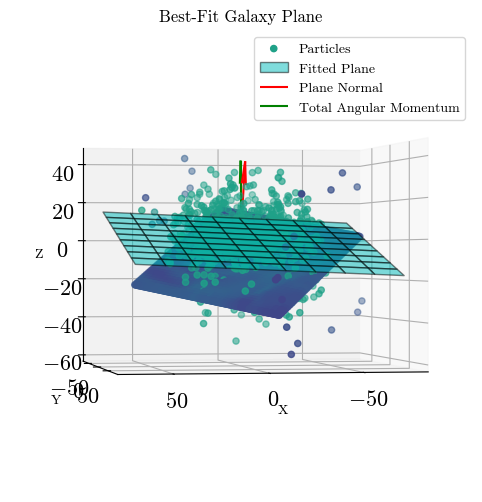

9.92093853122199


In [25]:
centroid = np.average(rotated_points, axis=0, weights=massdata)

# Compute the mass-weighted inertia tensor
I = np.zeros((3, 3))
for i in range(0, len(massdata), 1000):
    r = rotated_points[i]
    m = massdata[i]
    I += m * (np.dot(r, r) * np.eye(3) - np.outer(r, r))



# Compute eigenvectors and eigenvalues
eigenvalues, eigenvectors = np.linalg.eigh(I)

print(eigenvalues)

# The eigenvector corresponding to the largest eigenvalue is the normal to the plane
plane_normal = eigenvectors[:, 2]  # Largest eigenvalue

# Plane equation: n.r = d
A, B, C = plane_normal
D = -np.dot(plane_normal, centroid)

print(f"Plane equation: {A:.4f}x + {B:.4f}y + {C:.4f}z + {D:.4f} = 0")

x_vals = np.linspace(min(rotated_points[:, 0]), max(rotated_points[:, 0]), 10)
y_vals = np.linspace(min(rotated_points[:, 1]), max(rotated_points[:, 1]), 10)
X, Y = np.meshgrid(x_vals, y_vals)

# Solve for Z using Ax + By + Cz + D = 0 -> Z = (-A*X - B*Y - D) / C
Z = (-A * X - B * Y - D) / C

# Plot 3D points and the best-fit plane
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of particles
ax.scatter(rotated_points[::1000][:, 0], rotated_points[::1000][:, 1], rotated_points[::1000][:, 2], c=np.log10(massdata[::1000]), marker='o', label="Particles")

# Plot the plane
ax.plot_surface(X, Y, Z, alpha=0.5, color='cyan', edgecolor='k', label="Fitted Plane")

plane_normal = plane_normal/np.linalg.norm(plane_normal)
ax.quiver(0, 0, 0, plane_normal[0]*40, plane_normal[1]*40, plane_normal[2]*40, color='r', label="Plane Normal")

total_angular_momentum_unit_v = np.sum(L, axis=0)/np.linalg.norm(np.sum(L, axis=0))

ax.quiver(0, 0, 0, total_angular_momentum_unit_v[0]*40, total_angular_momentum_unit_v[1]*40, total_angular_momentum_unit_v[2]*40, color='g', label="Total Angular Momentum")


ax.view_init(elev=0, azim=80)
# Labels and legend
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title("Best-Fit Galaxy Plane")
plt.legend()
plt.show()

cos_theta = np.dot(plane_normal, total_angular_momentum_unit_v)

theta = np.arccos(cos_theta)/(2*np.pi)*360

print(theta)

In [26]:
#Now we want to calculate the rotation curve of the galaxy
#We want to plot the vr, vtheta and vz against r for the particles
#Create different bins of r and calculate the average vr, vtheta and vz for each bin

from dynamics import bins_calc

cylindrical_shells = cylindrical_points[:,0] #r points


variables = defaultdict(list)
variables['vr'] = cylindrical_velocities[:, 0]
variables['vtheta'] = cylindrical_velocities[:, 1]
variables['vz'] = cylindrical_velocities[:, 2]
variables['modv'] = np.sqrt(cylindrical_velocities[:, 0]**2 + cylindrical_velocities[:, 1]**2 + cylindrical_velocities[:, 2]**2)


mean_r, mean_variables, upper_variables, lower_variables = bins_calc(variables, cylindrical_shells, number_of_bins=1000)


##Calculating the mean of the speeds in the bin of radius r

##We also want to calulate the 68% confidence interval of the speeds in the bin of radius r
##np.quantile(vtheta_list, (1-0.68)/2) i.e. (np.quantile(vtheta_list,0.16)) gives the lower bound,
##and np.quantile(vtheta_list, 0.84) givesthe upper bound

#Finding interval which captures 68% of speeds in the bin (1 standard deviation)

for key in mean_variables.keys():
    mean_variables[key] = np.array(mean_variables[key])
    upper_variables[key] = np.array(upper_variables[key])
    lower_variables[key] = np.array(lower_variables[key])


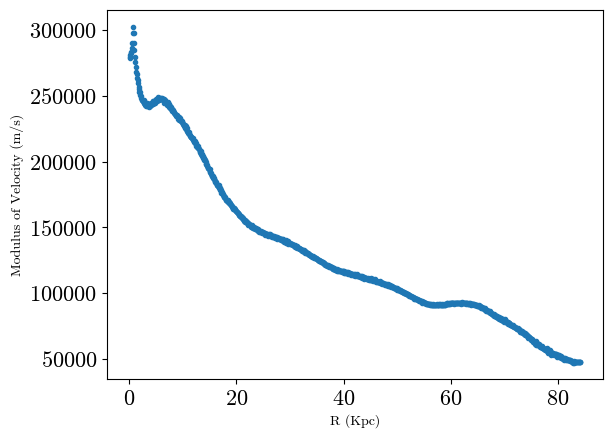

In [27]:
#Plot modulus of velocity against r

plt.plot(mean_r, mean_variables['modv']*kpc_to_m, '.')
plt.xlabel('R (Kpc)')
plt.ylabel('Modulus of Velocity (m/s)')
plt.show()

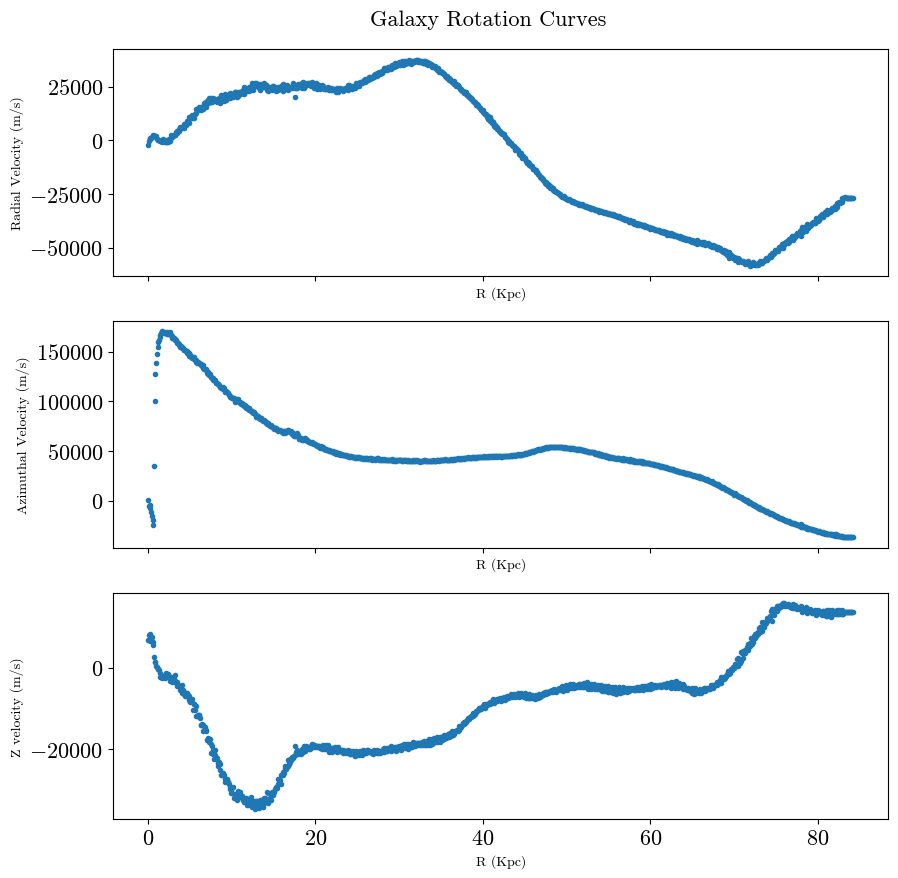

In [28]:
#Plotting galaxy rotation curves

figure, axis = plt.subplots(3, sharex=True, figsize=(10, 10))
figure.suptitle('Galaxy Rotation Curves', fontsize=16, y = 0.92)

axis[0].plot(mean_r, mean_variables['vr']*kpc_to_m, '.')
axis[0].set_xlabel('R (Kpc)')
axis[0].set_ylabel('Radial Velocity (m/s)')

axis[1].plot(mean_r, mean_variables['vtheta']*kpc_to_m, '.')
axis[1].set_xlabel('R (Kpc)')
axis[1].set_ylabel('Azimuthal Velocity (m/s)')


axis[2].plot(mean_r, mean_variables['vz']*kpc_to_m, '.')
axis[2].set_xlabel('R (Kpc)')
axis[2].set_ylabel('Z velocity (m/s)')

plt.show()

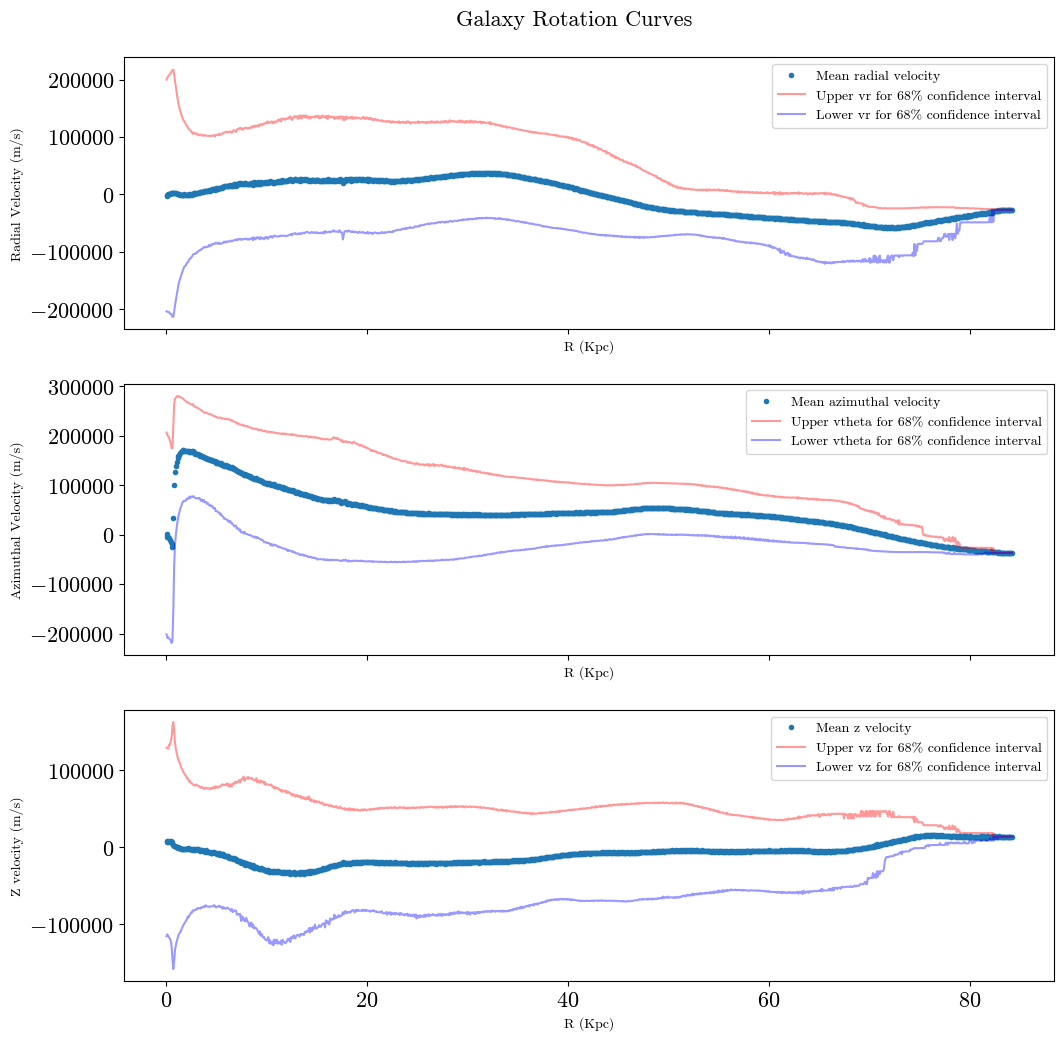

In [29]:
figure, axis = plt.subplots(3, sharex=True, figsize=(12, 12))
figure.suptitle('Galaxy Rotation Curves', fontsize=16, y = 0.92)



axis[0].plot(mean_r, mean_variables['vr']*kpc_to_m, '.', label = 'Mean radial velocity')
axis[0].set_xlabel('R (Kpc)')
axis[0].set_ylabel('Radial Velocity (m/s)')
axis[0].plot(mean_r, upper_variables['vr']*kpc_to_m, 'r', label = 'Upper vr for 68% confidence interval', alpha = 0.4)
axis[0].plot(mean_r, lower_variables['vr']*kpc_to_m, 'b', label = 'Lower vr for 68% confidence interval', alpha = 0.4)
axis[0].legend()


axis[1].plot(mean_r, mean_variables['vtheta']*kpc_to_m, '.', label = 'Mean azimuthal velocity')
axis[1].set_xlabel('R (Kpc)')
axis[1].set_ylabel('Azimuthal Velocity (m/s)')
axis[1].plot(mean_r, upper_variables['vtheta']*kpc_to_m, 'r', label = 'Upper vtheta for 68% confidence interval', alpha = 0.4)
axis[1].plot(mean_r, lower_variables['vtheta']*kpc_to_m, 'b', label = 'Lower vtheta for 68% confidence interval', alpha = 0.4)
axis[1].legend()


axis[2].plot(mean_r, mean_variables['vz']*kpc_to_m, '.', label = 'Mean z velocity')
axis[2].set_xlabel('R (Kpc)')
axis[2].set_ylabel('Z velocity (m/s)')
axis[2].plot(mean_r, upper_variables['vz']*kpc_to_m, 'r', label = 'Upper vz for 68% confidence interval', alpha = 0.4)
axis[2].plot(mean_r, lower_variables['vz']*kpc_to_m, 'b', label = 'Lower vz for 68% confidence interval', alpha = 0.4)
axis[2].legend()

plt.show()


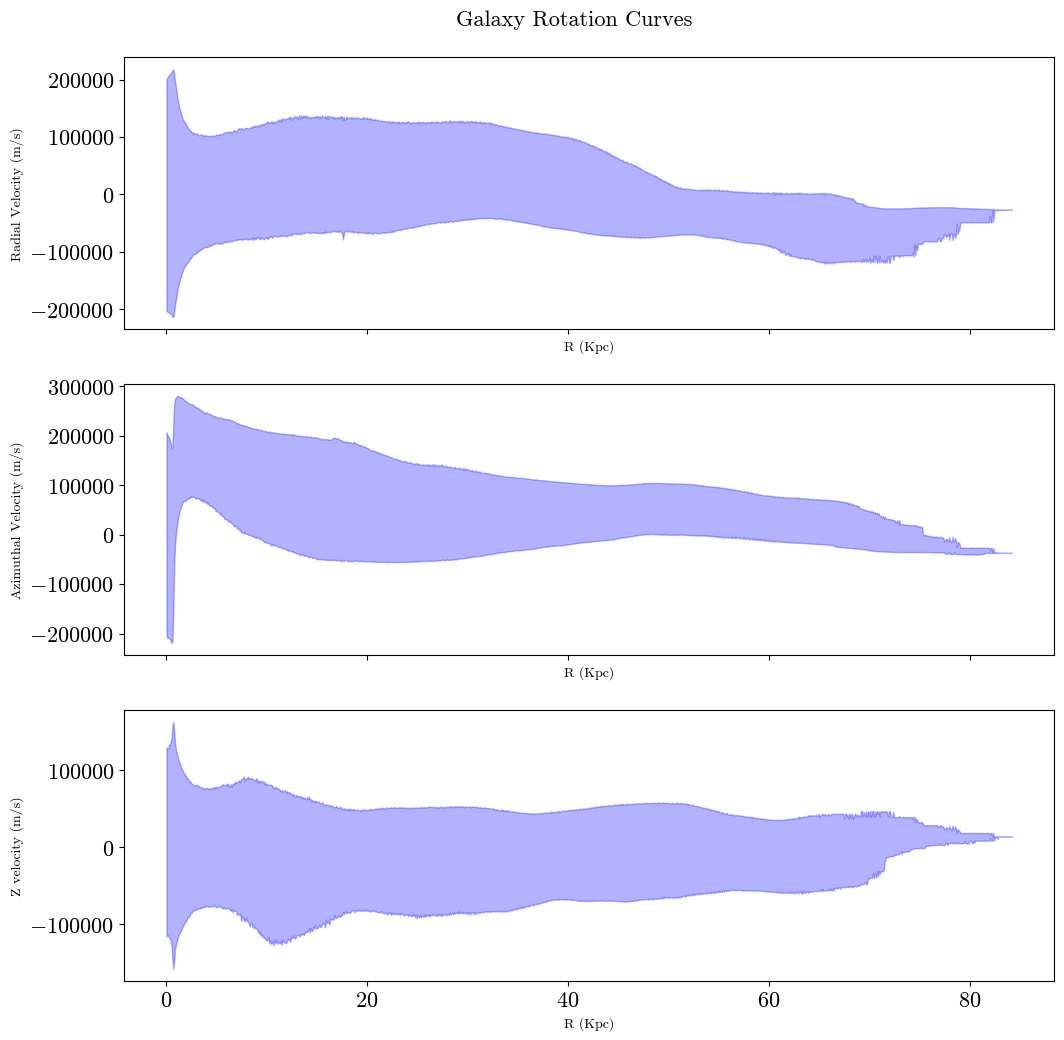

In [30]:
figure, axis = plt.subplots(3, sharex=True, figsize=(12, 12))
figure.suptitle('Galaxy Rotation Curves', fontsize=16, y = 0.92)

axis[0].set_xlabel('R (Kpc)')
axis[0].set_ylabel('Radial Velocity (m/s)')
axis[0].fill_between(mean_r, lower_variables['vr']*kpc_to_m, upper_variables['vr']*kpc_to_m, color='blue', alpha=0.3)


axis[1].set_xlabel('R (Kpc)')
axis[1].set_ylabel('Azimuthal Velocity (m/s)')
axis[1].fill_between(mean_r, lower_variables['vtheta']*kpc_to_m, upper_variables['vtheta']*kpc_to_m, color='blue', alpha=0.3)


axis[2].set_xlabel('R (Kpc)')
axis[2].set_ylabel('Z velocity (m/s)')
axis[2].fill_between(mean_r, lower_variables['vz']*kpc_to_m, upper_variables['vz']*kpc_to_m, color='blue', alpha=0.3)



plt.show()

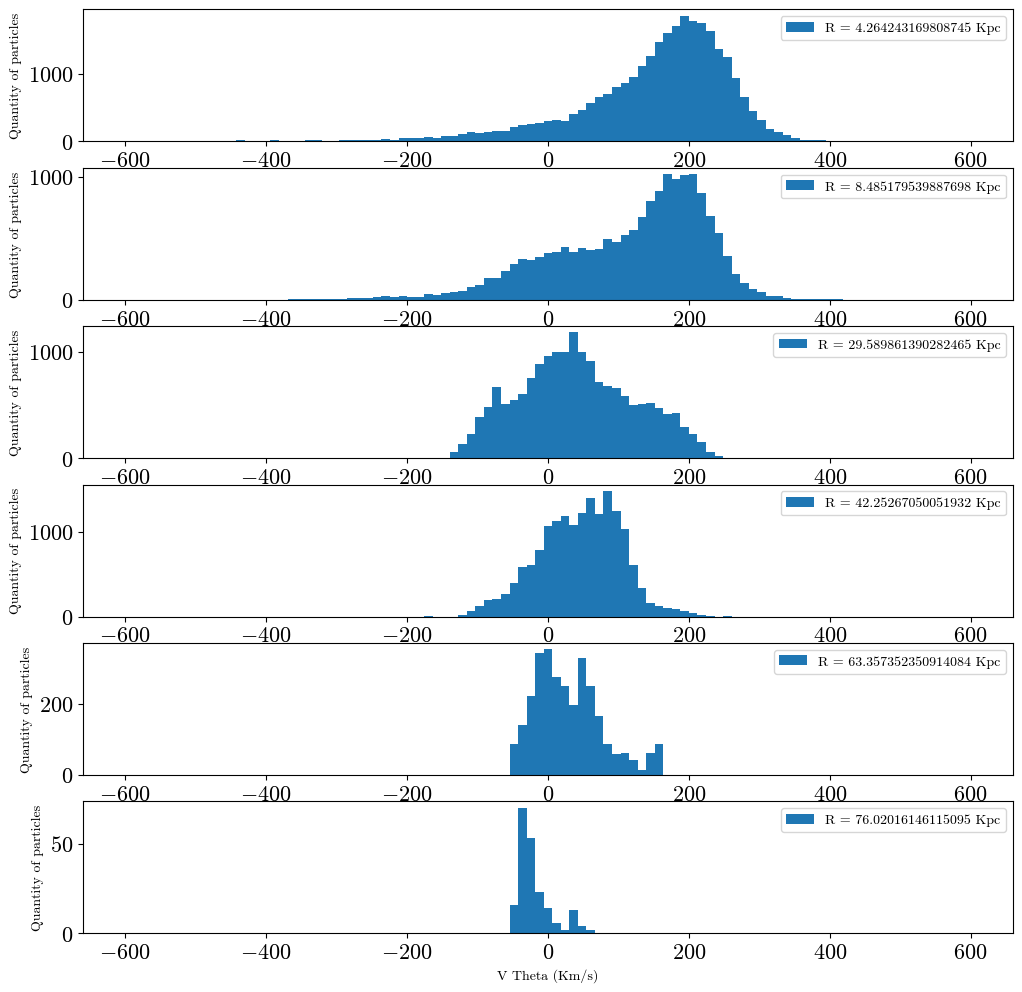

In [31]:
#Want to plot a histogram of the velocities vtheta for certain bins of r

number_of_bins = 1000

bins_of_interest = [50,100,350, 500, 750, 900] #from 0 to 1000

min_r = min(cylindrical_shells)
max_r = max(cylindrical_shells)

length_of_bins = (max_r - min_r)/number_of_bins

v_theta_hist = defaultdict(list)
z_plot = defaultdict(list)
x_plot = defaultdict(list)

for bin_of_interest in bins_of_interest:
    minr_in_bin = bin_of_interest*length_of_bins+min_r
    maxr_in_bin = (bin_of_interest+1)*length_of_bins+min_r
    mask = (cylindrical_shells > minr_in_bin) & (cylindrical_shells < maxr_in_bin)

    v_theta_hist[bin_of_interest] = cylindrical_velocities[mask, 1]
    z_plot[bin_of_interest] = cylindrical_points[mask, 2]

figure, axis = plt.subplots(len(bins_of_interest), figsize=(12, 12))

for i in range(len(v_theta_hist)):
    axis[i].hist(v_theta_hist[list(v_theta_hist.keys())[i]]*kpc_to_m/1000, bins = np.linspace(-600,600,100), label = 'R = '+str((list(v_theta_hist.keys())[i]+1/2)*length_of_bins+min_r)+' Kpc')
    axis[i].set_xlabel('V Theta (Km/s)')
    axis[i].set_ylabel('Quantity of particles')
    axis[i].legend()
plt.show()


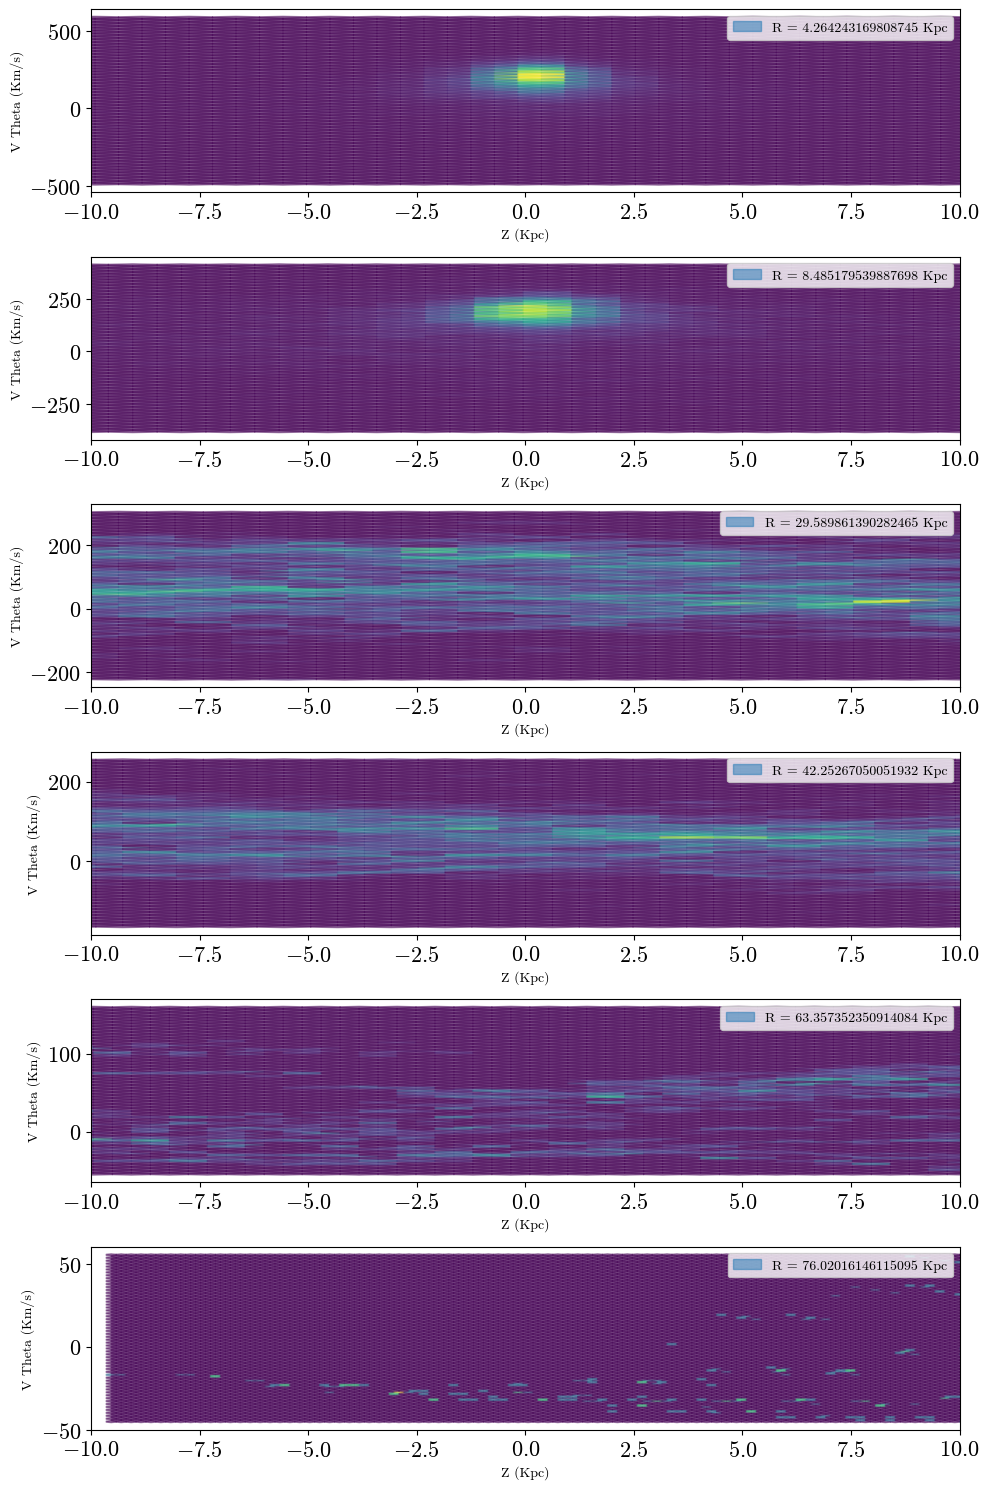

In [32]:
figure, axis = plt.subplots(len(bins_of_interest), figsize=(10, 15))

for i in range(len(v_theta_hist)):
    axis[i].hexbin(z_plot[list(v_theta_hist.keys())[i]],v_theta_hist[list(v_theta_hist.keys())[i]]*kpc_to_m/1000, label = 'R = '+str((list(v_theta_hist.keys())[i]+1/2)*length_of_bins+min_r)+' Kpc', alpha = 0.5)
    axis[i].set_xlabel('Z (Kpc)')
    axis[i].set_ylabel('V Theta (Km/s)')
    axis[i].set_xlim(-10,10)
    axis[i].legend()

plt.tight_layout()
plt.show()

9.9 Kpc < R < 10.1 Kpc and -0.1 Kpc < Z < 0.1 Kpc


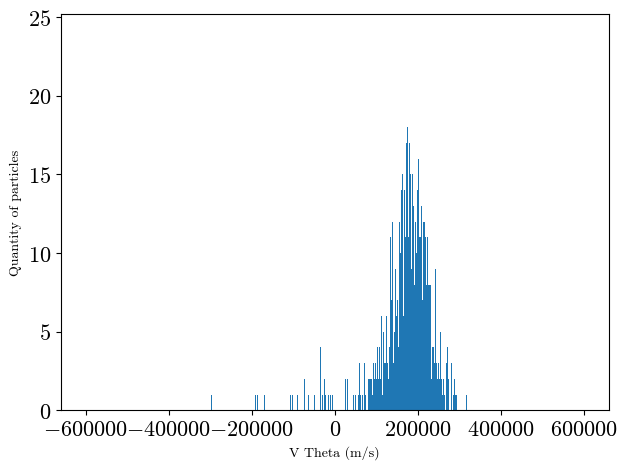

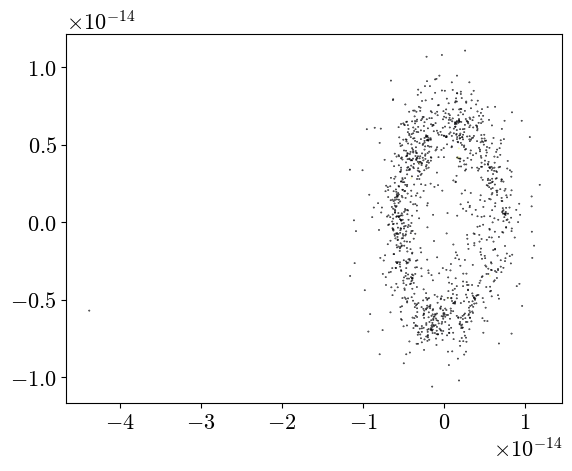

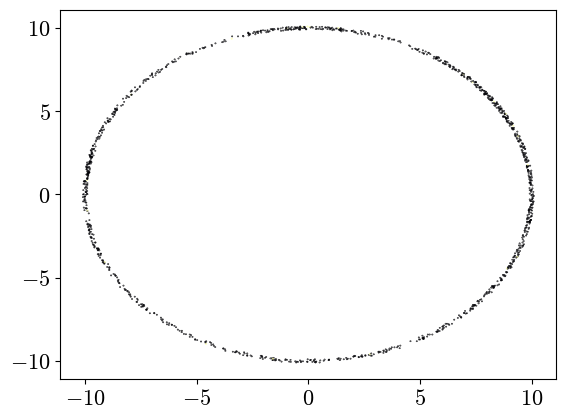

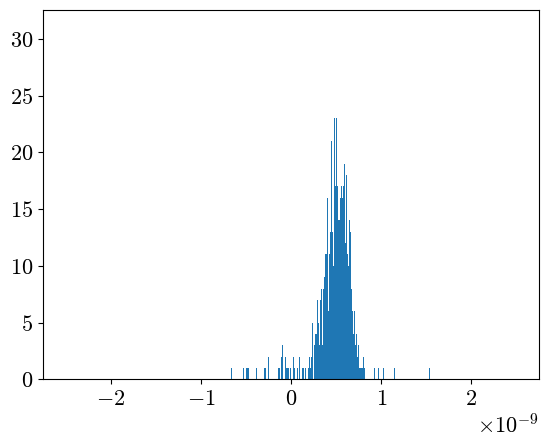

In [33]:
z_boundary = 0.1
r_boundary = 10

mask = ((cylindrical_points[:,2] < z_boundary) & (cylindrical_points[:,2] > -z_boundary)) & ((cylindrical_points[:,0] < r_boundary+0.1) & (cylindrical_points[:,0] > r_boundary-0.1))

hist_vtheta_2 = cylindrical_velocities[mask, 1] * kpc_to_m

print(r_boundary-0.1,'Kpc < R <',r_boundary+0.1,'Kpc and',-z_boundary,'Kpc < Z <',z_boundary,'Kpc')

plt.hist(hist_vtheta_2, bins = np.linspace(-600000,600000, 1000))
plt.xlabel('V Theta (m/s)')
plt.ylabel('Quantity of particles')
plt.tight_layout()
plt.show()

plt.hexbin(velocities_rotated[mask,0], velocities_rotated[mask,1], gridsize = 1000, cmap = 'inferno', bins = 'log')
plt.show()

plt.hexbin(rotated_points[mask,0], rotated_points[mask,1], gridsize = 1000, cmap = 'inferno', bins = 'log')
plt.show()

plt.hist(L[mask,2], bins = np.linspace(-0.25e-8, 0.25e-8, 1000))
plt.show()

In [34]:
#Now we want to calculate acceleration of particles as a function of radius 
#Acceleration is given by a = v^2/r
#We want to calculate the acceleration in the radial direction for each particle and then average it for each bin

#Already have mean r array

gas_cylindrical_shells = gas_cylindrical_points[:,0] #r points

number_of_bins = 30

max_r = 50

bins = np.linspace(0, max_r, number_of_bins+1)
bincenters = (bins[1:] + bins[:-1])/2


mean_acc_obs = []
mean_v_theta = []

for i in range(number_of_bins):

    max_r_for_bin = bins[i+1]
    min_r_for_bin = bins[i]

    mask = (gas_cylindrical_shells > min_r_for_bin) & (gas_cylindrical_shells < max_r_for_bin)

    vtheta_in_bin = cylindrical_gas_velocities[:,1][mask]

    if i == 0:
        print(len(vtheta_in_bin), 'particles in bin', i, 'with radius', min_r_for_bin, 'to', max_r_for_bin)
        print(np.sum(gas_masses[mask]))

    if len(vtheta_in_bin) == 0:
        mean_acc_obs.append(0)
        mean_v_theta.append(0)
    else:

        mean_a_in_bin = np.nanmean(vtheta_in_bin**2/(gas_cylindrical_shells[mask]))

        mean_acc_obs.append(mean_a_in_bin)

        mean_v_theta.append(np.nanmean(vtheta_in_bin))

mean_acc_obs = np.array(mean_acc_obs)*kpc_to_m
mean_v_theta = np.array(mean_v_theta)*kpc_to_m



8968 particles in bin 0 with radius 0.0 to 1.6666666666666667
301862321.57961655 Msun/kpc**3


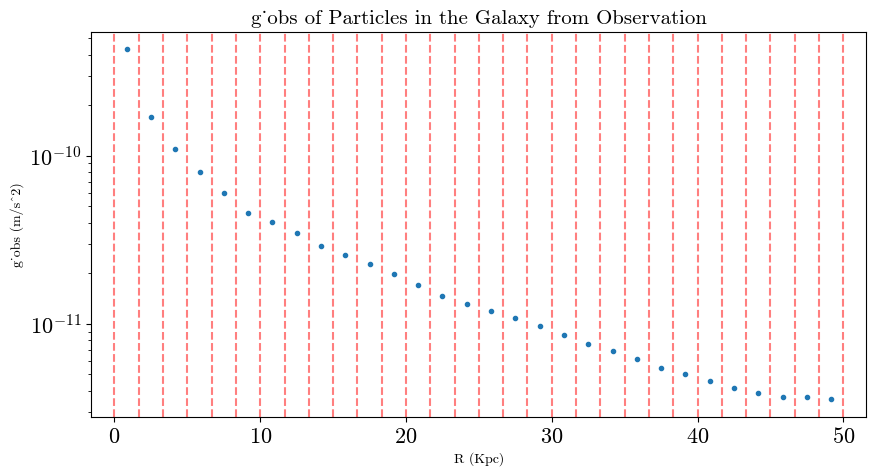

In [35]:
fig, ax = plt.subplots(figsize =(10, 5))

plt.plot(bincenters, mean_acc_obs, '.')

for i in bins:
    plt.axvline(x=i, color='r', linestyle='--', alpha = 0.5)



plt.xlabel('R (Kpc)')
plt.ylabel('g_obs (m/s^2)')
plt.yscale('log')
plt.title('g_obs of Particles in the Galaxy from Observation', size=15)
plt.show()


In [36]:
#We found acceleration that is observed by the rotational velocity using a = v_theta^2/r
#Now we want to calculate the acceleration that is observed by the mass distribution using a = GM/r^2
#We want to compare the two accelerations

mean_acc_bar = []

cylindrical_shells = cylindrical_points[:,0] #r points

for i in range(len(bincenters)):
    bin = bincenters[i]
    r_in_m = bin*kpc_to_m
    mask = (rdata < bin)
    if i == 0:
        print(np.sum(massdata[mask]), 'particles in bin', i, 'with radius', bin)
    inside_mass = np.sum(massdata[mask]*Msun)
    mean_acc_bar.append(constants.G*inside_mass/(r_in_m**2))



8920747246.878885 particles in bin 0 with radius 0.8333333333333334


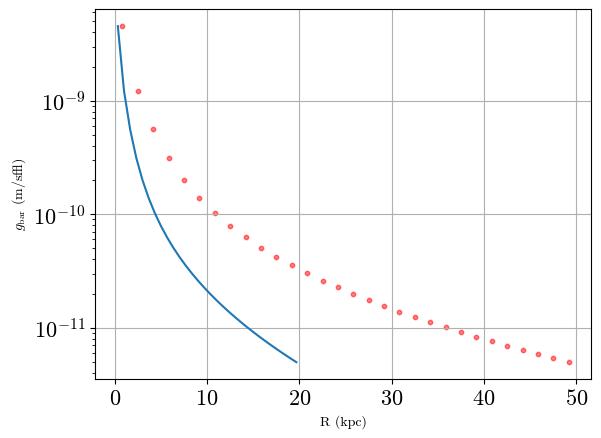

In [37]:
from dynamics import compute_g_bar_radial

R, g_bar = compute_g_bar_radial(cylindrical_shells, massdata, 30, 20)


plt.plot(R, g_bar)
plt.scatter(bincenters, g_bar, label = 'g_bar from mass distribution', color = 'red', s = 10, alpha = 0.5)
plt.xlabel("R (kpc)")
plt.ylabel(r"$g_{\mathrm{bar}}$ (m/s²)")
plt.yscale('log')
plt.grid()
plt.show()


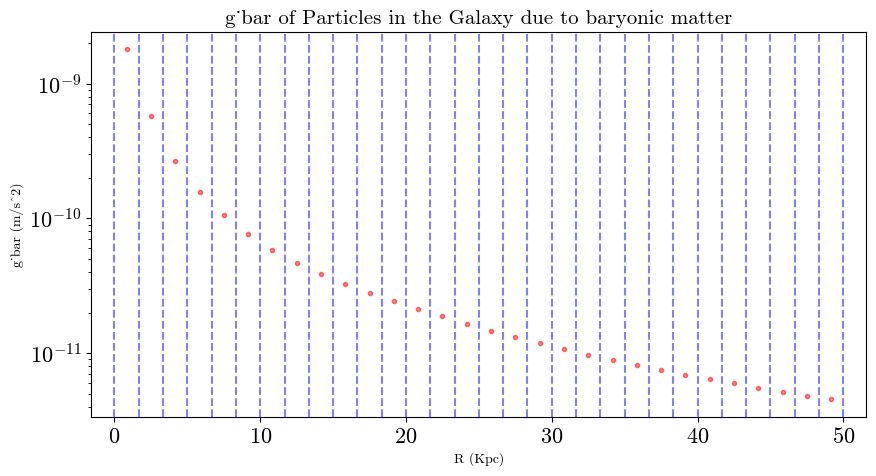

In [38]:
fig, ax = plt.subplots(figsize =(10, 5))
mean_acc_bar = np.array(mean_acc_bar)


plt.xlabel('R (Kpc)')
plt.ylabel('g_bar (m/s^2)')
plt.title('g_bar of Particles in the Galaxy due to baryonic matter', size=15)
plt.yscale('log')
plt.plot(bincenters, mean_acc_bar, '.', color = 'r', alpha = 0.5)

for i in bins:
    plt.axvline(x=i, color='b', linestyle='--', alpha = 0.5)

plt.show()


30


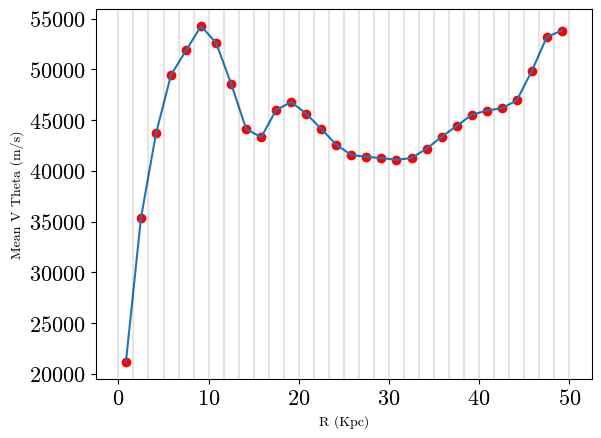

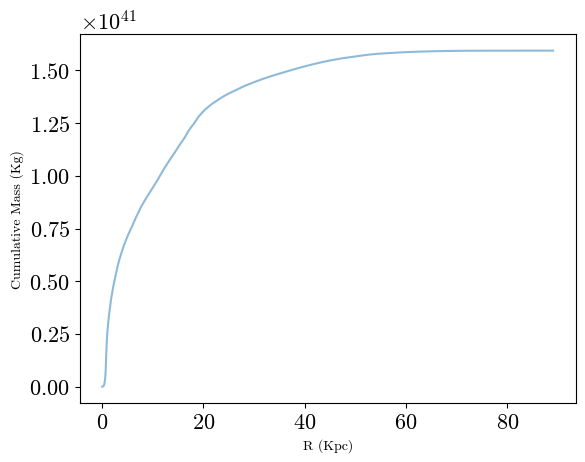

/mnt/users/darnej/miniconda3/envs/ozyenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


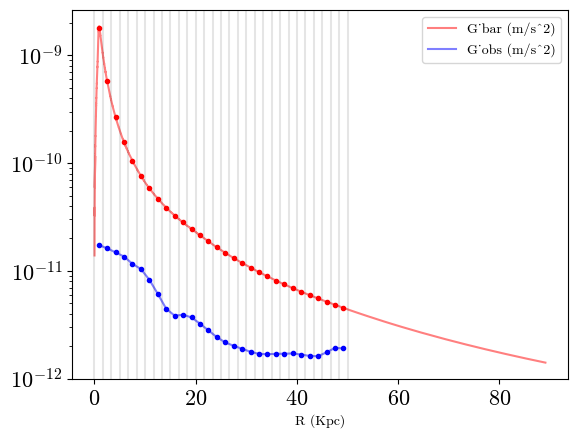

In [39]:
mask = mean_v_theta > 0
bincenters = bincenters[mask]
mean_v_theta = mean_v_theta[mask]
mean_acc_bar = mean_acc_bar[mask]

print(len(mean_acc_bar))

plt.plot(bincenters, mean_v_theta)

for bin in bins:
    plt.axvline(bin, color='k', alpha = 0.1)

plt.scatter(bincenters, mean_v_theta, color = 'r', label = 'Mean V Theta')


plt.xlabel('R (Kpc)')
plt.ylabel('Mean V Theta (m/s)')
plt.show()

mapping = np.argsort(rdata)
rdata_sorted = np.array(rdata[mapping])
massdata_sorted = np.array(massdata[mapping])
cum_mass = np.cumsum(massdata_sorted)*Msun

plt.plot(rdata_sorted, cum_mass, alpha = 0.5)

G_bar = constants.G*cum_mass/(rdata_sorted*kpc_to_m)**2

plt.xlabel('R (Kpc)')
plt.ylabel('Cumulative Mass (Kg)')
plt.show()

plt.plot(rdata_sorted, G_bar, color = 'red', label = 'G_bar (m/s^2)', alpha = 0.5)
plt.plot(bincenters, mean_v_theta**2/(bincenters*kpc_to_m), color = 'blue', label = 'G_obs (m/s^2)', alpha = 0.5)


for bin in bins:
    plt.axvline(bin, color='k', alpha = 0.1)

plt.plot(bincenters, mean_v_theta**2/(bincenters*kpc_to_m), '.', color = 'b')
plt.plot(bincenters, mean_acc_bar, '.', color = 'r')
plt.yscale('log')
plt.xlabel('R (Kpc)')
plt.legend()
plt.show()


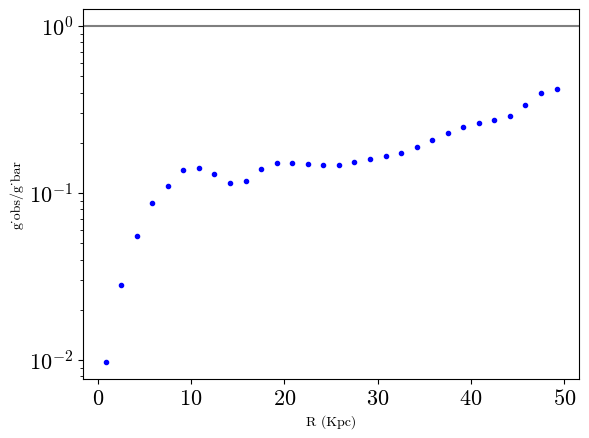

In [40]:
mean_acc_obs = mean_v_theta**2/(bincenters*kpc_to_m)
plt.plot(bincenters, mean_acc_obs/mean_acc_bar, '.', color = 'b')
plt.xlabel('R (Kpc)')
plt.ylabel('g_obs/g_bar')
plt.yscale('log')
plt.axhline(1, color='k', alpha = 0.5)
plt.show()

[1.79065694e-09 5.73971066e-10 2.66642209e-10 1.55902141e-10
 1.05111672e-10 7.61292769e-11 5.82808048e-11 4.68249810e-11
 3.85728650e-11 3.25755517e-11 2.81146739e-11 2.44975484e-11
 2.13992240e-11 1.87544301e-11 1.65589227e-11 1.47034881e-11
 1.31545730e-11 1.18349817e-11 1.07033443e-11 9.72789760e-12
 8.87879832e-12 8.13716199e-12 7.48845120e-12 6.91672467e-12
 6.40804195e-12 5.95302201e-12 5.54406539e-12 5.17459800e-12
 4.83882770e-12 4.53365254e-12]
[1.73912648e-11 1.61946724e-11 1.48374048e-11 1.35760926e-11
 1.16194610e-11 1.04028522e-11 8.27525198e-12 6.11767425e-12
 4.45161436e-12 3.83856983e-12 3.91856631e-12 3.69776659e-12
 3.23725944e-12 2.80288190e-12 2.42880287e-12 2.16629633e-12
 2.01737234e-12 1.89087613e-12 1.77366323e-12 1.69697078e-12
 1.68675399e-12 1.69904091e-12 1.70413263e-12 1.71304507e-12
 1.67448878e-12 1.62418876e-12 1.61544452e-12 1.75480595e-12
 1.92866493e-12 1.90891138e-12]


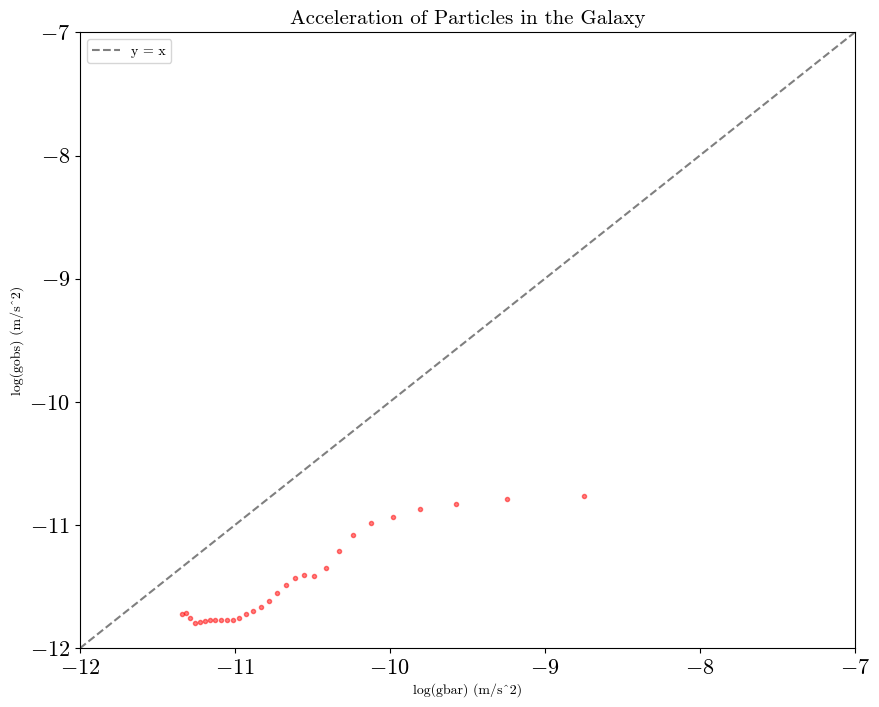

In [41]:
fig, ax = plt.subplots(figsize =(10, 8))

x = np.linspace(-12, -7, 100)
y = x

plt.plot(x, y, linestyle = '--', color = 'black', label = 'y = x', alpha = 0.5)

print(mean_acc_bar)
print(mean_acc_obs)

plt.xlabel('log(gbar) (m/s^2)')
plt.ylabel('log(gobs) (m/s^2)')
plt.title('Acceleration of Particles in the Galaxy', size=15)
plt.plot(np.log10(mean_acc_bar), np.log10(mean_acc_obs), '.', color = 'r', alpha = 0.5)

plt.xlim(-12, -7)
plt.ylim(-12, -7)
plt.legend()
plt.show()


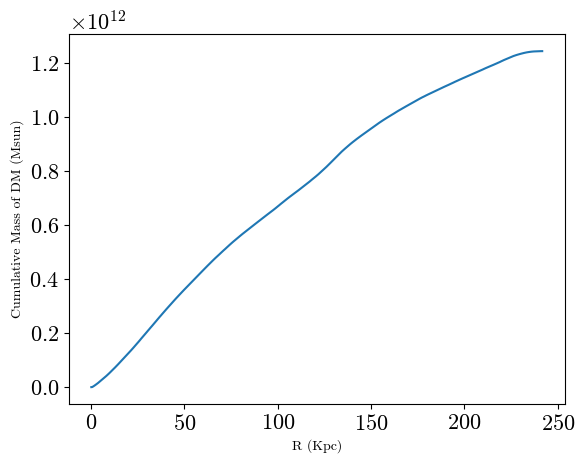

In [42]:
#Finding g_dm

dm_mapping = np.argsort(dm_rdata)

dm_rdata_sorted = np.array(dm_rdata[dm_mapping])

dm_massdata_sorted = np.array(dm_massdata[dm_mapping])

dm_cum_mass = np.cumsum(dm_massdata_sorted)

plt.plot(dm_rdata_sorted, dm_cum_mass)
plt.xlabel('R (Kpc)')
plt.ylabel('Cumulative Mass of DM (Msun)')
plt.show()

In [43]:
number_of_bins = 1000
max_r = dm_rdata_sorted[-1]
min_r = dm_rdata_sorted[0]
length_of_bins = (max_r - min_r)/number_of_bins


dm_mean_acc_bar = []
dm_mean_r = []
for i in range(number_of_bins):
    maxr_in_bin = min_r + (i+1)*length_of_bins
    minr_in_bin = min_r + i*length_of_bins
    dm_r = (maxr_in_bin + minr_in_bin)/2
    r_in_m = dm_r * kpc_to_m
    dm_mean_r.append(dm_r)
    mask = dm_rdata_sorted < dm_r
    dm_inside_mass = np.sum(dm_massdata_sorted[mask]*Msun)
    dm_mean_acc_bar.append(constants.G*inside_mass/(r_in_m**2))

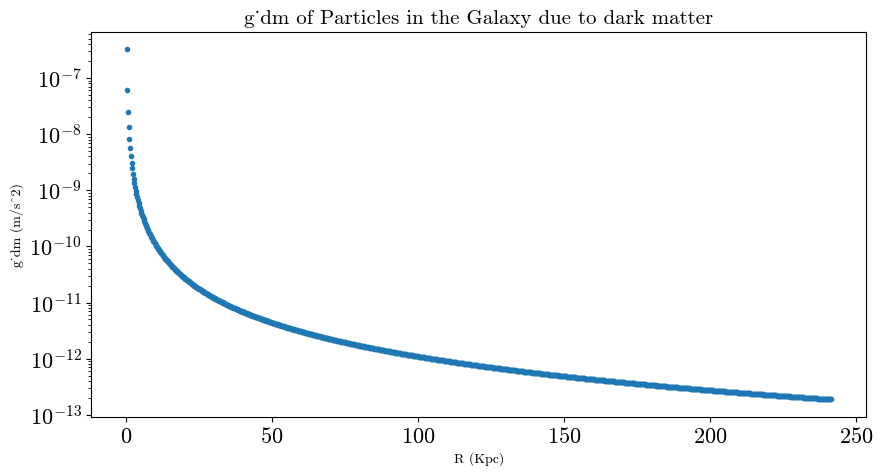

In [44]:
fig, ax = plt.subplots(figsize =(10, 5))

plt.plot(dm_mean_r, dm_mean_acc_bar, '.')
plt.xlabel('R (Kpc)')
plt.ylabel('g_dm (m/s^2)')
plt.yscale('log')
plt.title('g_dm of Particles in the Galaxy due to dark matter', size=15)
plt.show()

In [45]:
#Finding g_total

number_of_bins = 2000
max_r = max(dm_rdata_sorted[-1], rdata_sorted[-1])
min_r = min(dm_rdata_sorted[0], rdata_sorted[0])
length_of_bins = (max_r - min_r)/number_of_bins


total_mean_acc_bar = []
total_mean_r = []
mean_acc_bar_large_r = []

for i in range(number_of_bins):
    maxr_in_bin = min_r + (i+1)*length_of_bins
    minr_in_bin = min_r + i*length_of_bins
    meanr = (maxr_in_bin + minr_in_bin)/2
    r_in_m = meanr * kpc_to_m
    total_mean_r.append(meanr)

    dm_mask = dm_rdata_sorted < meanr 
    mask = rdata_sorted < meanr
    dm_inside_mass = np.sum(dm_massdata_sorted[dm_mask]*Msun)
    inside_mass = np.sum(massdata_sorted[mask]*Msun)
    total_inside_mass = dm_inside_mass + inside_mass
    total_mean_acc_bar.append(constants.G*total_inside_mass/(r_in_m**2))
    mean_acc_bar_large_r.append(constants.G*inside_mass/(r_in_m**2))


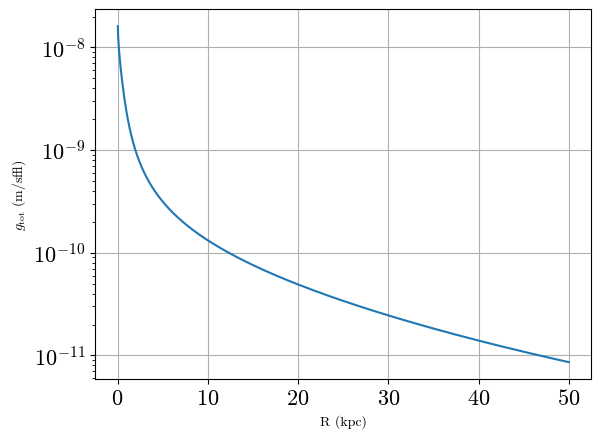

In [46]:
from dynamics import compute_g_bar_radial

cylindrical_shells_dm = cylindrical_points_dm[:,0] #r points

all_cylindrical_shells = np.append(cylindrical_shells, cylindrical_shells_dm)
all_massdata = np.append(massdata, dm_massdata)

R, g_tot = compute_g_bar_radial(all_cylindrical_shells, all_massdata, 1000, 50)


plt.plot(R, g_tot)
plt.xlabel("R (kpc)")
plt.ylabel(r"$g_{\mathrm{tot}}$ (m/s²)")
plt.yscale('log')
plt.grid()
plt.show()

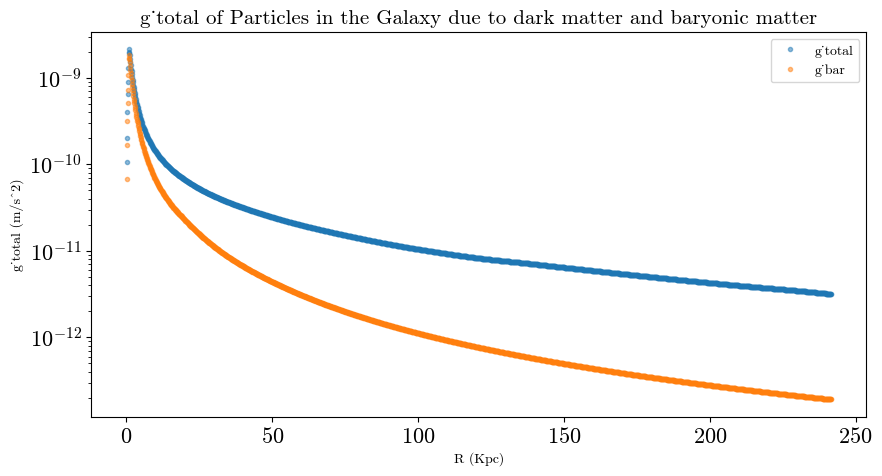

In [47]:
fig, ax = plt.subplots(figsize =(10, 5))

plt.plot(total_mean_r, total_mean_acc_bar, '.', label = 'g_total', alpha = 0.5)
plt.plot(total_mean_r, mean_acc_bar_large_r, '.', label = 'g_bar', alpha = 0.5)
plt.xlabel('R (Kpc)')
plt.ylabel('g_total (m/s^2)')
plt.yscale('log')
plt.title('g_total of Particles in the Galaxy due to dark matter and baryonic matter', size=15)
plt.legend()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (1000,) and (30,)

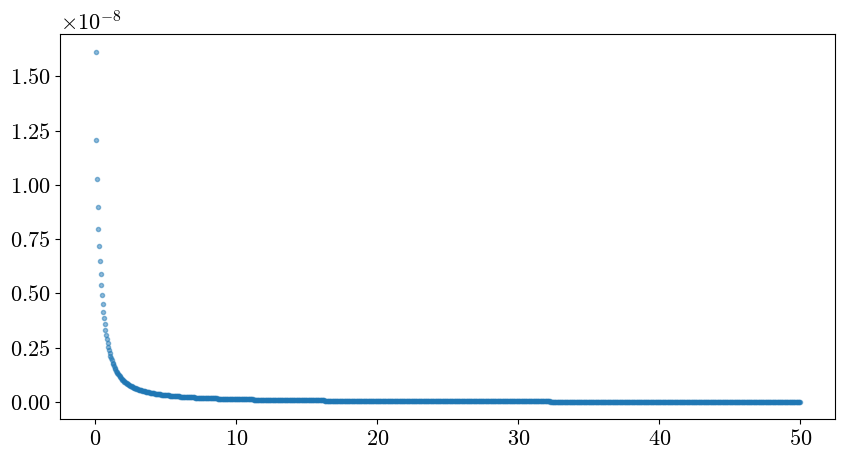

In [48]:
fig, ax = plt.subplots(figsize =(10, 5))

plt.plot(R, g_tot, '.', label = 'g_total', alpha = 0.5)
plt.plot(R, mean_acc_obs, '.', label = 'g_obs', alpha = 0.5)
plt.xlabel('R (Kpc)')
plt.ylabel('g (m/s^2)')
plt.yscale('log')
#plt.xlim(0, 20)
plt.title('g_total of Particles in the Galaxy due to dark matter and baryonic matter', size=15)
plt.legend()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (7,) and (2000,)

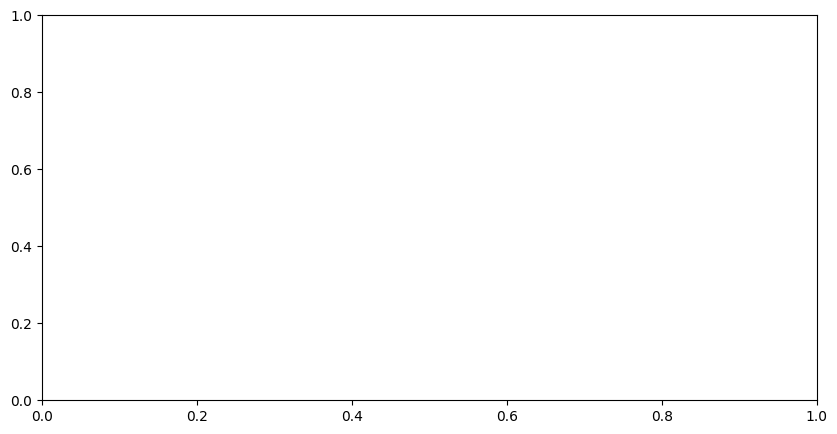

In [ ]:
fig, ax = plt.subplots(figsize =(10, 5))

plt.plot(np.log10(mean_acc_bar), np.log10(total_mean_acc_bar), '.', label = 'g_total', alpha = 0.5)

x = np.linspace(-12, -7, 100)
y = x

plt.plot(x, y, linestyle = '--', color = 'black', label = 'y = x', alpha = 0.5)


plt.show()

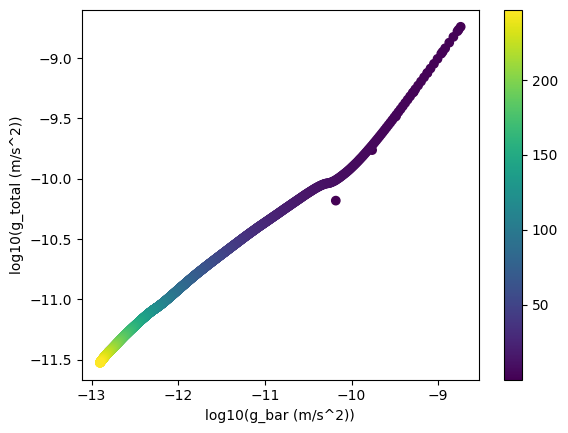

In [ ]:
plt.scatter(np.log10(mean_acc_bar_large_r), np.log10(total_mean_acc_bar), c=total_mean_r)
plt.colorbar()
plt.xlabel('log10(g_bar (m/s^2))')
plt.ylabel('log10(g_total (m/s^2))')
plt.show()

In [ ]:
import pandas as pd

csv_star = pd.read_csv('/mnt/users/darnej/MPhys/Stars_pytree/accelerations_star_8.csv')
csv_total = pd.read_csv('/mnt/users/darnej/MPhys/Total_pytree/accelerations_total_8.csv')

kpc_to_m = 3.086e+19
G = 6.67430e-11
Msun = 1.989e30

a_r_star = np.array(csv_star['a_r']/(kpc_to_m**2)*G*Msun)
a_theta_star = np.array(csv_star['a_theta']/(kpc_to_m**2)*G*Msun)
a_z_star = np.array(csv_star['a_z']/(kpc_to_m**2)*G*Msun)

a_r_total = np.array(csv_total['a_r_total']/(kpc_to_m**2)*G*Msun)
a_theta_total = np.array(csv_total['a_theta_total']/(kpc_to_m**2)*G*Msun)
a_z_total = np.array(csv_total['a_z_total']/(kpc_to_m**2)*G*Msun)

print(len(a_r_star))
print(len(a_r_total))



1456568
1456568


In [ ]:
csv_r_half = pd.read_csv('/mnt/users/darnej/MPhys/R_half/r_half_8.csv')

r_half = np.array(csv_r_half['r_half'])[0]*length_multiplier

print('R_half is',r_half)


R_half is 4.097345507285249 kpc


In [ ]:

mask = (cylindrical_shells < 5*r_half) & (abs(rotated_points[:,2]) < 0.1)

Rdata_5r_12 = (cylindrical_shells[mask])

print(Rdata_5r_12[0], Rdata_5r_12[-1])

number_of_bins = 1000
max_r = max(Rdata_5r_12)
min_r = 0
length_of_bins = (max_r - min_r)/number_of_bins
mean_a_r_py = []
mean_a_theta_py = [] 
mean_a_z_py = []
mean_a_r_total_py = []
mean_r = []

for i in range(number_of_bins):
    maxr_in_bin = min_r + (i+1)*length_of_bins
    minr_in_bin = min_r + i*length_of_bins
    mean_r.append((maxr_in_bin + minr_in_bin)/2)

    mask = ((Rdata_5r_12 > minr_in_bin) & (Rdata_5r_12 < maxr_in_bin))

    mean_a_r_py.append(-np.mean(a_r_star[mask]))
    mean_a_theta_py.append(np.mean(a_theta_star[mask]))
    mean_a_z_py.append(np.mean(a_z_star[mask]))

    mean_a_r_total_py.append(abs(np.mean(a_r_total[mask])))


0.009030630291182727 20.486625684979256


IndexError: boolean index did not match indexed array along axis 0; size of axis is 1456568 but size of corresponding boolean axis is 480109

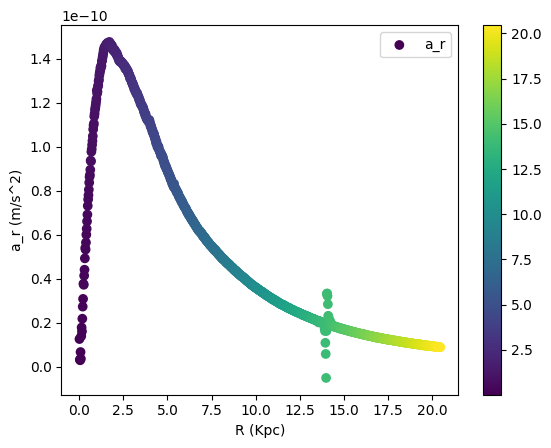

In [ ]:
plt.scatter(mean_r, mean_a_r_py, label = 'a_r', c=mean_r)
plt.colorbar()
#plt.plot(mean_r, mean_a_theta_py, '.', label = 'a_theta')
#plt.plot(mean_r, mean_a_z_py, '.', label = 'a_z')
plt.legend()
plt.xlabel('R (Kpc)')
plt.ylabel('a_r (m/s^2)')
plt.show()

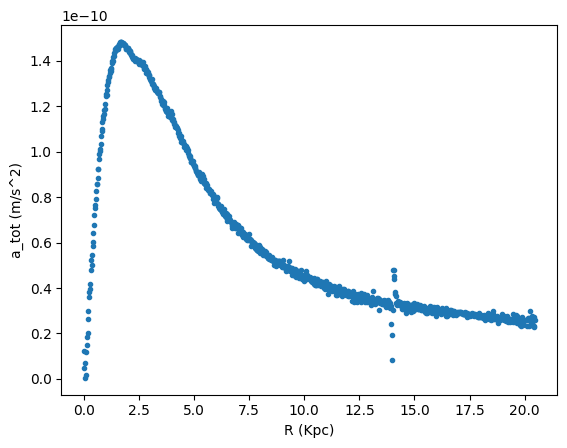

In [ ]:
plt.plot(mean_r, mean_a_r_total_py, '.')
plt.xlabel('R (Kpc)')
plt.ylabel('a_tot (m/s^2)')
plt.show()

/tmp/ipykernel_2565593/1494685043.py:6: RuntimeWarning: invalid value encountered in log10
  max_x = max(max(np.log10(mean_a_r_py)), max(np.log10(mean_a_r_total_py)))
/tmp/ipykernel_2565593/1494685043.py:7: RuntimeWarning: invalid value encountered in log10
  min_x = min(min(np.log10(mean_a_r_py)), min(np.log10(mean_a_r_total_py)))
/tmp/ipykernel_2565593/1494685043.py:12: RuntimeWarning: invalid value encountered in log10
  plt.scatter(np.log10(mean_a_r_py), np.log10(mean_a_r_total_py), c = mean_r, s = 5)


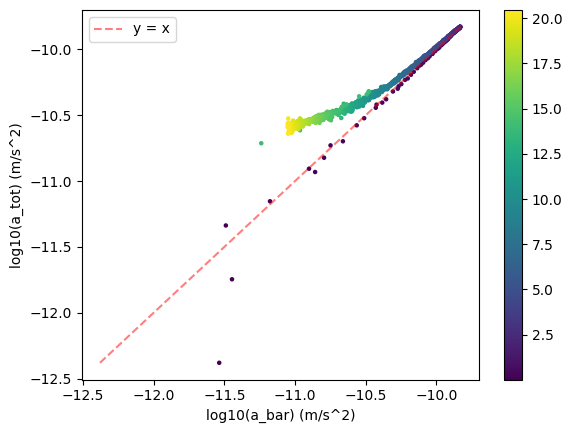

In [ ]:
mean_r = [x for x in mean_r if not np.isnan(mean_a_r_py[mean_r.index(x)])]
mean_a_r_py = [x for x in mean_a_r_py if not np.isnan(x)]
mean_a_r_total_py = [x for x in mean_a_r_total_py if not np.isnan(x)]


max_x = max(max(np.log10(mean_a_r_py)), max(np.log10(mean_a_r_total_py)))
min_x = min(min(np.log10(mean_a_r_py)), min(np.log10(mean_a_r_total_py)))
x = np.linspace(min_x, max_x, len(mean_a_r_py))
y = x


plt.scatter(np.log10(mean_a_r_py), np.log10(mean_a_r_total_py), c = mean_r, s = 5)
plt.plot(x,y, linestyle = '--', color = 'r', alpha = 0.5, label = 'y = x')
plt.colorbar()
plt.legend()
plt.xlabel('log10(a_bar) (m/s^2)')
plt.ylabel('log10(a_tot) (m/s^2)')
plt.show()

/mnt/users/darnej/miniconda3/envs/ozyenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


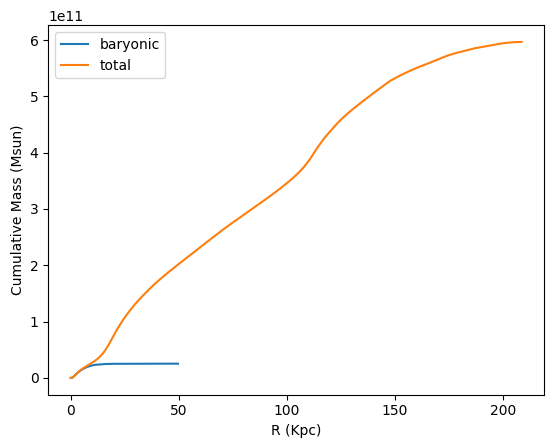

In [ ]:
total_masses = np.concatenate((massdata_sorted, dm_massdata_sorted))
r_data_total = np.concatenate((rdata_sorted, dm_rdata_sorted))

mapping = create_mapping(r_data_total)

total_masses = total_masses[mapping]
r_data_total = r_data_total[mapping]

total_cum_mass = np.cumsum(total_masses)

plt.plot(rdata_sorted, cum_mass, label = 'baryonic')
plt.plot(r_data_total, total_cum_mass, label = 'total')
plt.xlabel('R (Kpc)')
plt.ylabel('Cumulative Mass (Msun)')
plt.legend()
plt.show()

In [ ]:
from RAR_for_all_chosen import run

gal_number = 1

results = run(gal_number, ozy_file)



/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/stars_gal_1.hdf5
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/dm_gal_1.hdf5
Total mass of the galaxy is:  54620378705.901024
[[ 0.89905553 -0.42603022 -0.10098224]
 [-0.42603022 -0.7980355  -0.42618962]
 [ 0.10098224  0.42618962 -0.89897998]]
[[ 0.91066066 -0.40322432 -0.09004057]
 [-0.40322432 -0.81991336 -0.40638927]
 [ 0.09004057  0.40638927 -0.90925269]]


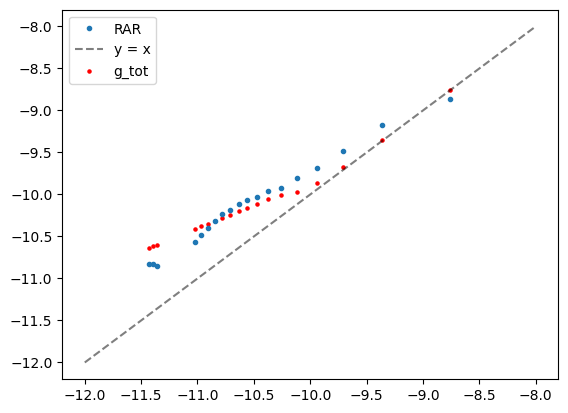

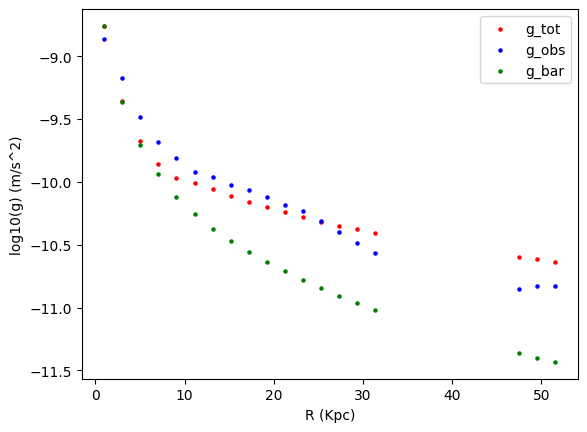

In [ ]:
g_bar = results['mean_acc_bar']
g_tot = results['total_mean_acc_bar']
g_obs = results['mean_acc_obs']
R = results['mean_r']

mask = g_obs > 0

g_bar = g_bar[mask]
g_tot = g_tot[mask]
R = R[mask]
g_obs = g_obs[mask]


plt.plot(np.log10(g_bar), np.log10(g_obs), '.', label = 'RAR')


x = np.linspace(-12, -8, 100)
y = x

plt.plot(x, y, linestyle = '--', color = 'black', label = 'y = x', alpha = 0.5)

plt.scatter(np.log10(g_bar), np.log10(g_tot), c = 'r', s = 5, label = 'g_tot')
plt.legend()

plt.show()

R = R[~np.isnan(g_tot)]
plt.scatter(R, np.log10(g_tot), c = 'r', s = 5, label = 'g_tot')
plt.scatter(R, np.log10(g_obs), c = 'b', s = 5, label = 'g_obs')
plt.scatter(R, np.log10(g_bar), c = 'g', s = 5, label = 'g_bar')
plt.xlabel('R (Kpc)')
plt.ylabel('log10(g) (m/s^2)')
plt.legend()
plt.show()
